In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import math
import calendar
import sys

sys.path.insert(0, "../utils")

from plots import *

enc = 'utf-8' 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
raw_data = pd.read_csv('../data/CM_MAL_cases_GID2_2015-2024_original.csv', encoding = enc)
raw_data.head()

,Region,District,Area,Health Facility,Year,Month Number,Malaria Hospitalizations - Under 5,Malaria Hospitalizations - Pregnant Women,Malaria Hospitalizations - 5 and Over,Total Malaria Hospitalizations,...,Severe Confirmed Cases - Pregnant Women,Total Severe Confirmed Cases,Malaria Deaths - Under 5,Malaria Deaths - 5 and Over,Malaria Deaths - Pregnant Women,Total Malaria Deaths,Confirmed Cases - Under 5,Confirmed Cases - 5 and Over,Confirmed Cases - Pregnant Women,Total Confirmed Malaria Cases
0,Extreme-Nord,District Bogo,AS Balaza,CSI Balaza Alcali,2015,1,3.0,2.0,12.0,17.0,...,2.0,17.0,0.0,0.0,0.0,0.0,49.0,43.0,2.0,94.0
1,Extreme-Nord,District Bogo,AS Balda,CSI Balda,2015,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,5.0,0.0,7.0
2,Extreme-Nord,District Bogo,AS Bogo,CSI Bogo,2015,1,0.0,0.0,0.0,0.0,...,0.0,68.0,0.0,0.0,0.0,0.0,19.0,53.0,0.0,72.0
3,Extreme-Nord,District Bogo,AS Bogo,HD Bogo,2015,1,1.0,0.0,0.0,1.0,...,3.0,15.0,0.0,0.0,0.0,0.0,6.0,10.0,3.0,19.0
4,Extreme-Nord,District Bogo,AS Borai,CSI Borai,2015,1,4.0,1.0,3.0,8.0,...,1.0,8.0,0.0,0.0,0.0,0.0,16.0,14.0,1.0,31.0


<Axes: >

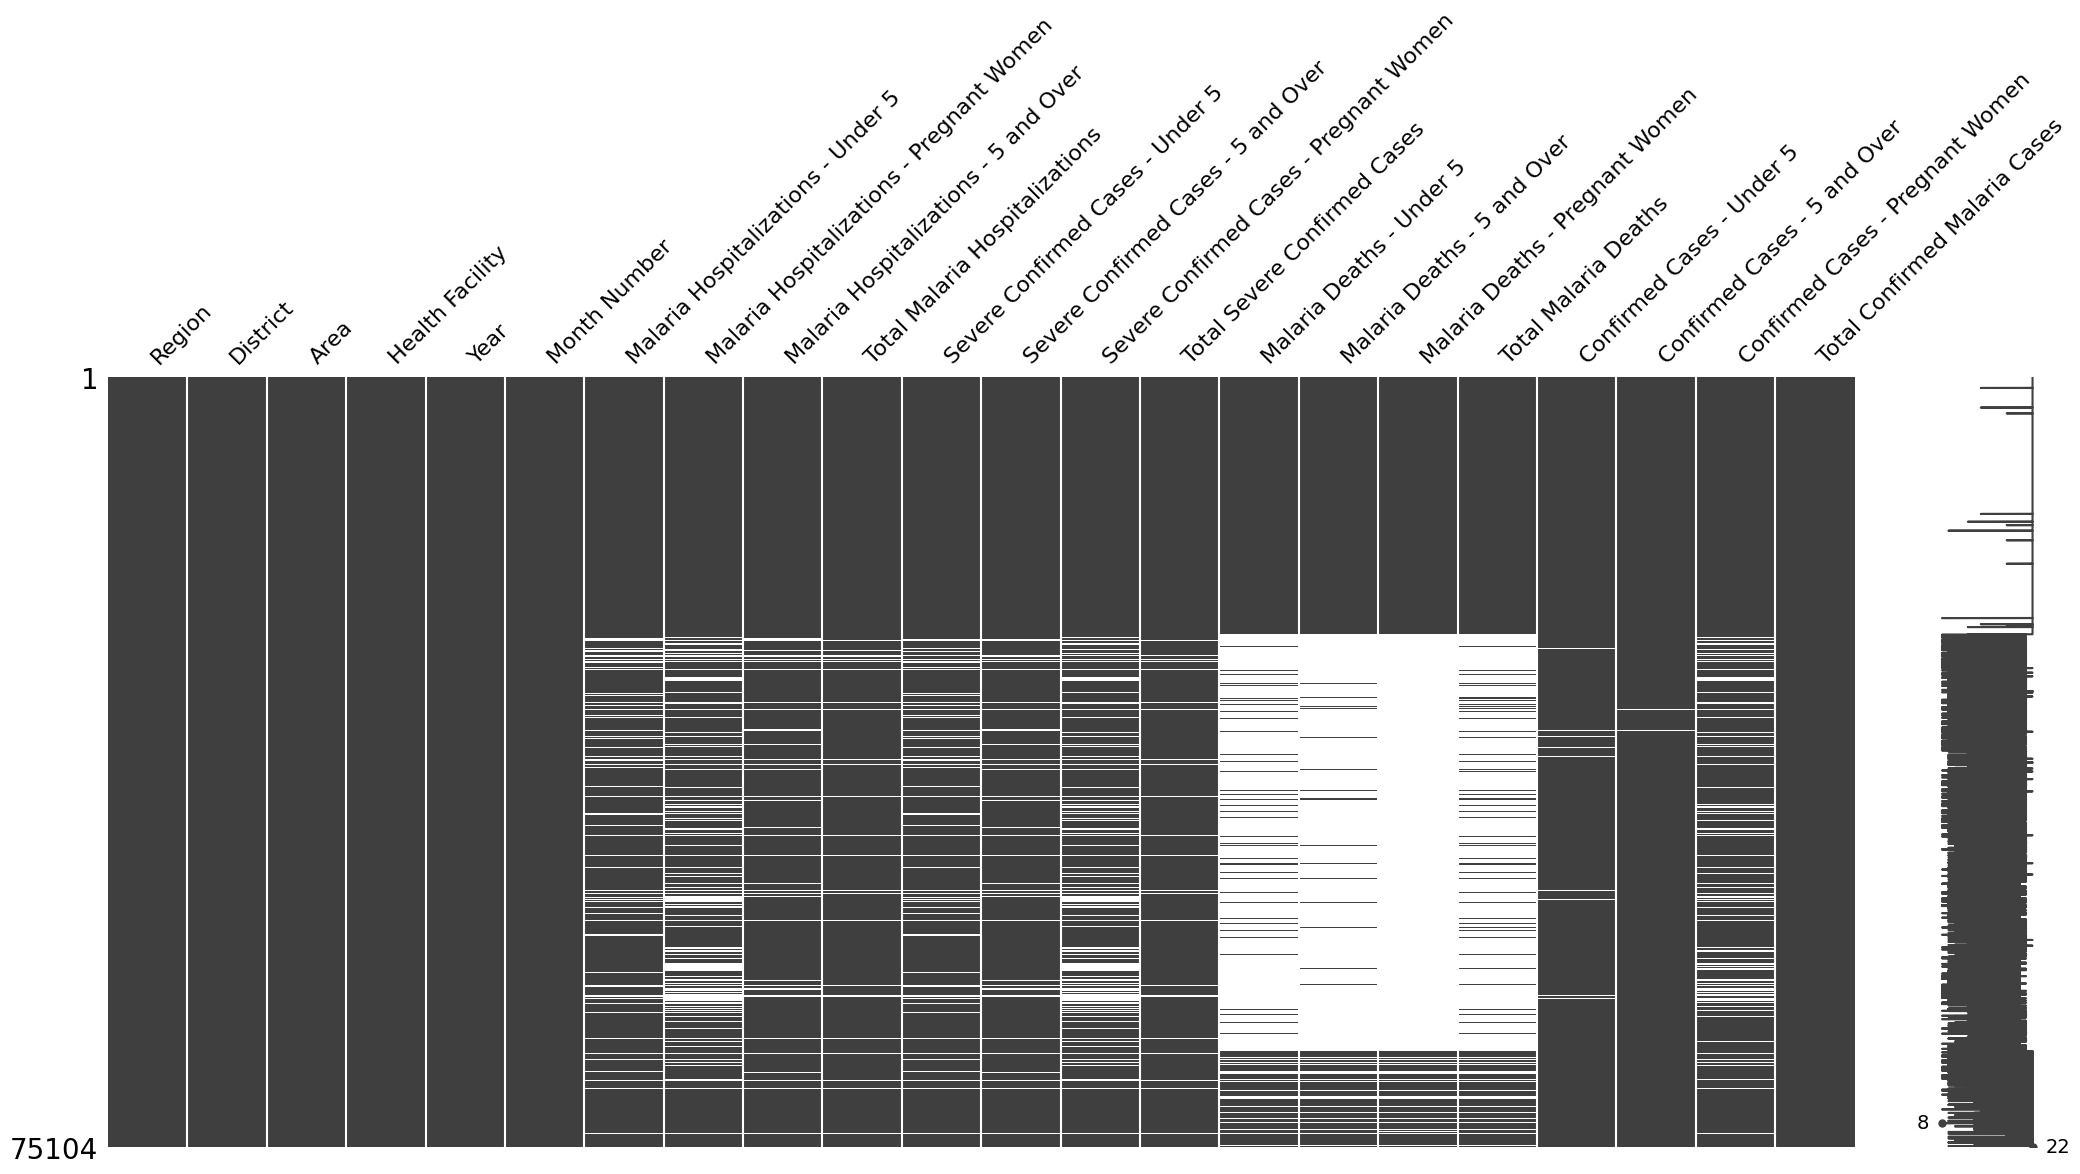

In [4]:
missingno.matrix(raw_data)

In [5]:
raw_data.District.sort_values().unique()

array(['District Bibemi', 'District Bogo', 'District Bourha',
       'District Figuil', 'District Fotokol', 'District Garoua 1',
       'District Garoua 2', 'District Gaschiga', 'District Gazawa',
       'District Golombe', 'District Goulfey', 'District Guere',
       'District Guider', 'District Guidiguis', 'District Hina',
       'District Kaele', 'District Kar Hay', 'District Kolofata',
       'District Kousseri', 'District Koza', 'District Lagdo',
       'District Mada', 'District Maga', 'District Makary',
       'District Maroua 1', 'District Maroua 2', 'District Maroua 3',
       'District Mayo Oulo', 'District Meri', 'District Mindif',
       'District Mogode', 'District Mokolo', 'District Mora',
       'District Moulvoudaye', 'District Moutourwa', 'District Mozogo',
       'District Ngong', 'District Pette', 'District Pitoa',
       'District Poli', 'District Rey Bouba', 'District Roua',
       'District Tchollire', 'District Tokombere', 'District Touboro',
       'District Vel

In [6]:
raw_data = raw_data.set_axis(['GID1', 'GID3', 'Area', 'Facility', 'Year', 'Month', 'Hosp_UND5', 'Hosp_PRGN', 'Hosp_OVR5', 'Hosp_TOTAL', 'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL', 'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL', 'Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL'], axis=1)

In [7]:
raw_data.head()

,GID1,GID3,Area,Facility,Year,Month,Hosp_UND5,Hosp_PRGN,Hosp_OVR5,Hosp_TOTAL,...,Sevr_PRGN,Sevr_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL
0,Extreme-Nord,District Bogo,AS Balaza,CSI Balaza Alcali,2015,1,3.0,2.0,12.0,17.0,...,2.0,17.0,0.0,0.0,0.0,0.0,49.0,43.0,2.0,94.0
1,Extreme-Nord,District Bogo,AS Balda,CSI Balda,2015,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,5.0,0.0,7.0
2,Extreme-Nord,District Bogo,AS Bogo,CSI Bogo,2015,1,0.0,0.0,0.0,0.0,...,0.0,68.0,0.0,0.0,0.0,0.0,19.0,53.0,0.0,72.0
3,Extreme-Nord,District Bogo,AS Bogo,HD Bogo,2015,1,1.0,0.0,0.0,1.0,...,3.0,15.0,0.0,0.0,0.0,0.0,6.0,10.0,3.0,19.0
4,Extreme-Nord,District Bogo,AS Borai,CSI Borai,2015,1,4.0,1.0,3.0,8.0,...,1.0,8.0,0.0,0.0,0.0,0.0,16.0,14.0,1.0,31.0


In [8]:
case_columns = ['Hosp_UND5', 'Hosp_PRGN', 'Hosp_OVR5', 'Hosp_TOTAL', 
                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL', 
                'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL', 
                'Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL']

In [9]:
# df_total_cases = raw_data.drop(columns = ['Area', 'Facility', 'Hosp_UND5', 'Hosp_PRGN', 'Hosp_OVR5', 'Hosp_TOTAL', 'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL', 'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL', 'Case_UND5', 'Case_OVR5', 'Case_PRGN',])
# df_total_cases.head()

In [10]:
raw_data.shape

(75104, 22)

In [11]:
raw_data.dropna(axis = 0, subset = case_columns, how = 'all', inplace = True)
raw_data.shape

(75104, 22)

<Axes: >

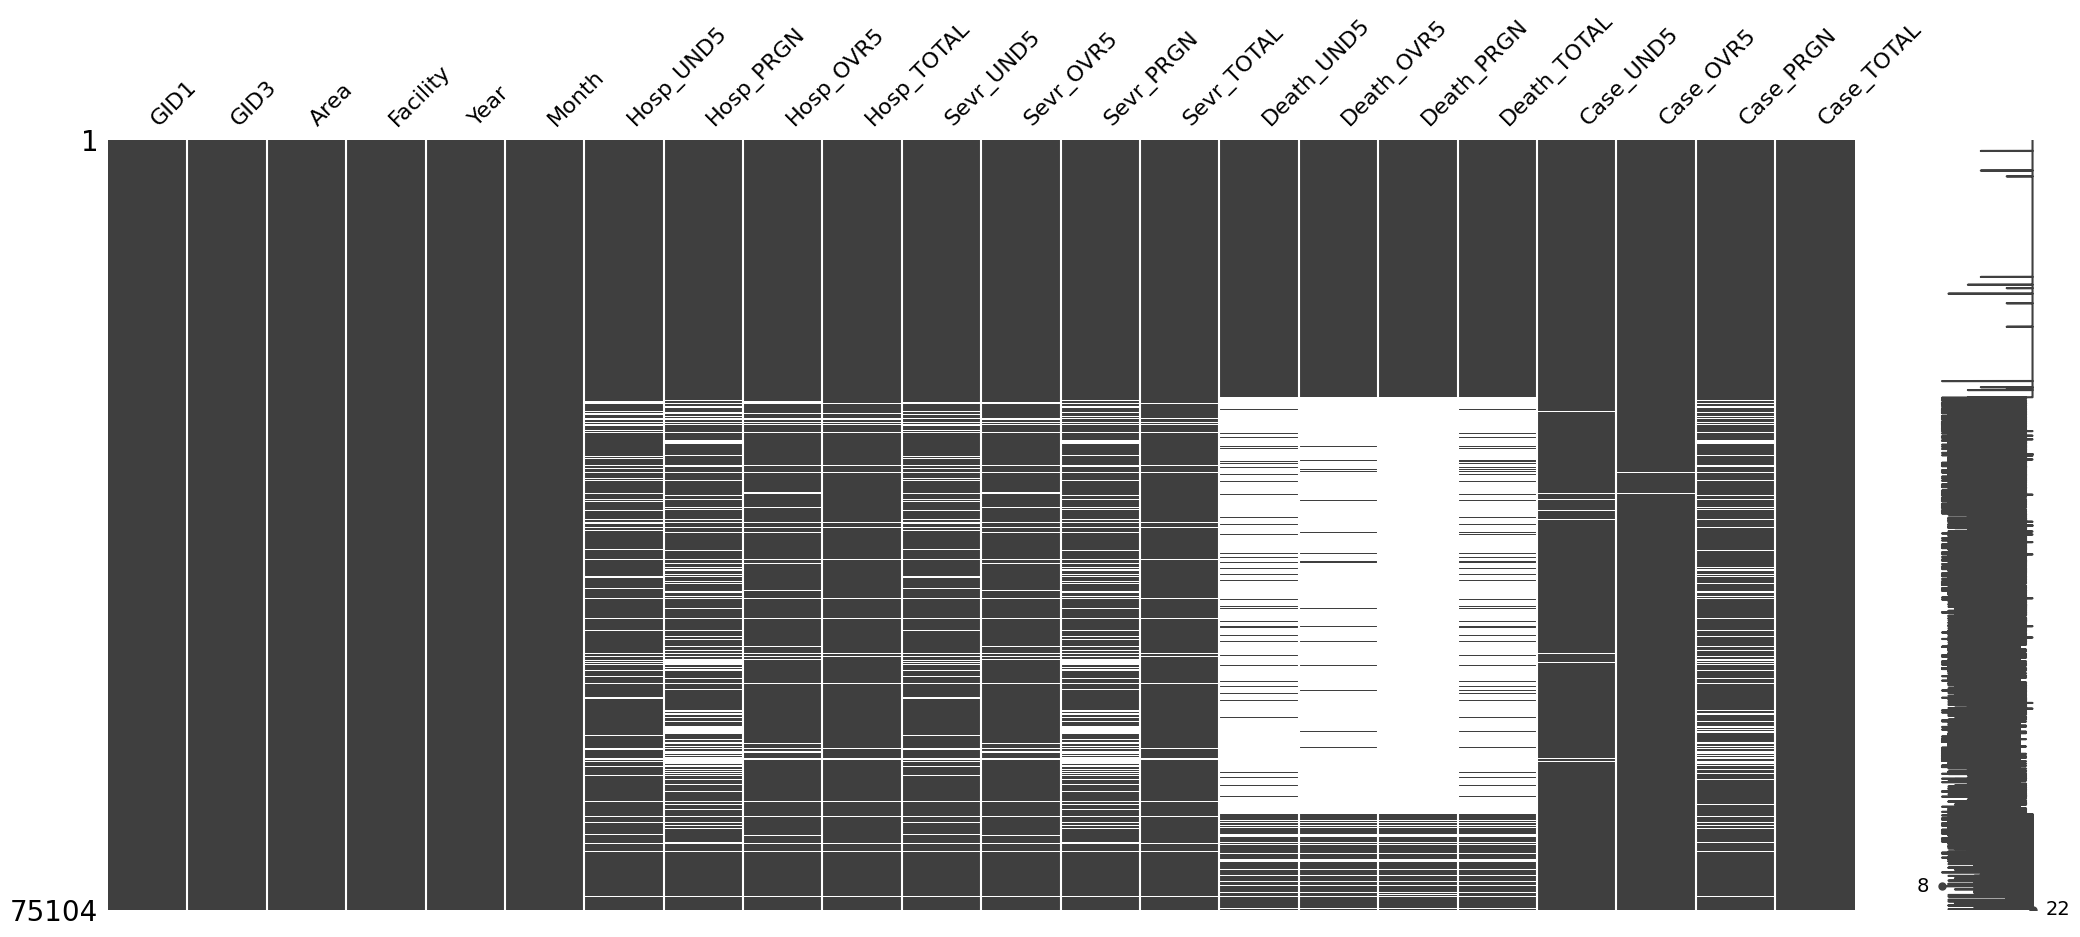

In [12]:
raw_data.reset_index(drop=True, inplace=True)
missingno.matrix(raw_data)

In [13]:
raw_data[case_columns] = raw_data[case_columns].astype('Int64') 


In [14]:
raw_data['dt_placement'] = pd.to_datetime(raw_data['Year'].astype(str) + '-' + raw_data['Month'].astype(str), format='%Y-%m')
raw_data['dt_placement'] = raw_data['dt_placement'].dt.strftime('%m-%Y')
raw_data.head()

,GID1,GID3,Area,Facility,Year,Month,Hosp_UND5,Hosp_PRGN,Hosp_OVR5,Hosp_TOTAL,...,Sevr_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,dt_placement
0,Extreme-Nord,District Bogo,AS Balaza,CSI Balaza Alcali,2015,1,3,2,12,17,...,17,0,0,0,0,49,43,2,94,01-2015
1,Extreme-Nord,District Bogo,AS Balda,CSI Balda,2015,1,0,0,0,0,...,0,0,0,0,0,2,5,0,7,01-2015
2,Extreme-Nord,District Bogo,AS Bogo,CSI Bogo,2015,1,0,0,0,0,...,68,0,0,0,0,19,53,0,72,01-2015
3,Extreme-Nord,District Bogo,AS Bogo,HD Bogo,2015,1,1,0,0,1,...,15,0,0,0,0,6,10,3,19,01-2015
4,Extreme-Nord,District Bogo,AS Borai,CSI Borai,2015,1,4,1,3,8,...,8,0,0,0,0,16,14,1,31,01-2015


In [15]:
raw_data['GID1'] = raw_data['GID1'].str.lower()
raw_data['GID3'] = raw_data['GID3'].str.lower()

raw_data['GID3'] = raw_data['GID3'].str.replace(r'^district ', '', regex=True)

In [16]:
raw_data.GID1.sort_values().unique()

array(['extreme-nord', 'nord'], dtype=object)

In [17]:
raw_data.GID3.sort_values().unique()

array(['bibemi', 'bogo', 'bourha', 'figuil', 'fotokol', 'garoua 1',
       'garoua 2', 'gaschiga', 'gazawa', 'golombe', 'goulfey', 'guere',
       'guider', 'guidiguis', 'hina', 'kaele', 'kar hay', 'kolofata',
       'kousseri', 'koza', 'lagdo', 'mada', 'maga', 'makary', 'maroua 1',
       'maroua 2', 'maroua 3', 'mayo oulo', 'meri', 'mindif', 'mogode',
       'mokolo', 'mora', 'moulvoudaye', 'moutourwa', 'mozogo', 'ngong',
       'pette', 'pitoa', 'poli', 'rey bouba', 'roua', 'tchollire',
       'tokombere', 'touboro', 'vele', 'waza', 'yagoua'], dtype=object)

In [18]:
df_hospitalizations = raw_data[['GID1', 'GID3', 'Area', 'Facility', 'Year', 'Month', 'dt_placement', 
                                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL']].copy()

df_severe = raw_data[['GID1', 'GID3', 'Area', 'Facility', 'Year', 'Month', 'dt_placement', 
                                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL']].copy()

df_deaths = raw_data[['GID1', 'GID3', 'Area', 'Facility', 'Year', 'Month', 'dt_placement', 
                                'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL']].copy()

df_cases = raw_data[['GID1', 'GID3', 'Area', 'Facility', 'Year', 'Month', 'dt_placement', 
                                'Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL']].copy()

<Axes: >

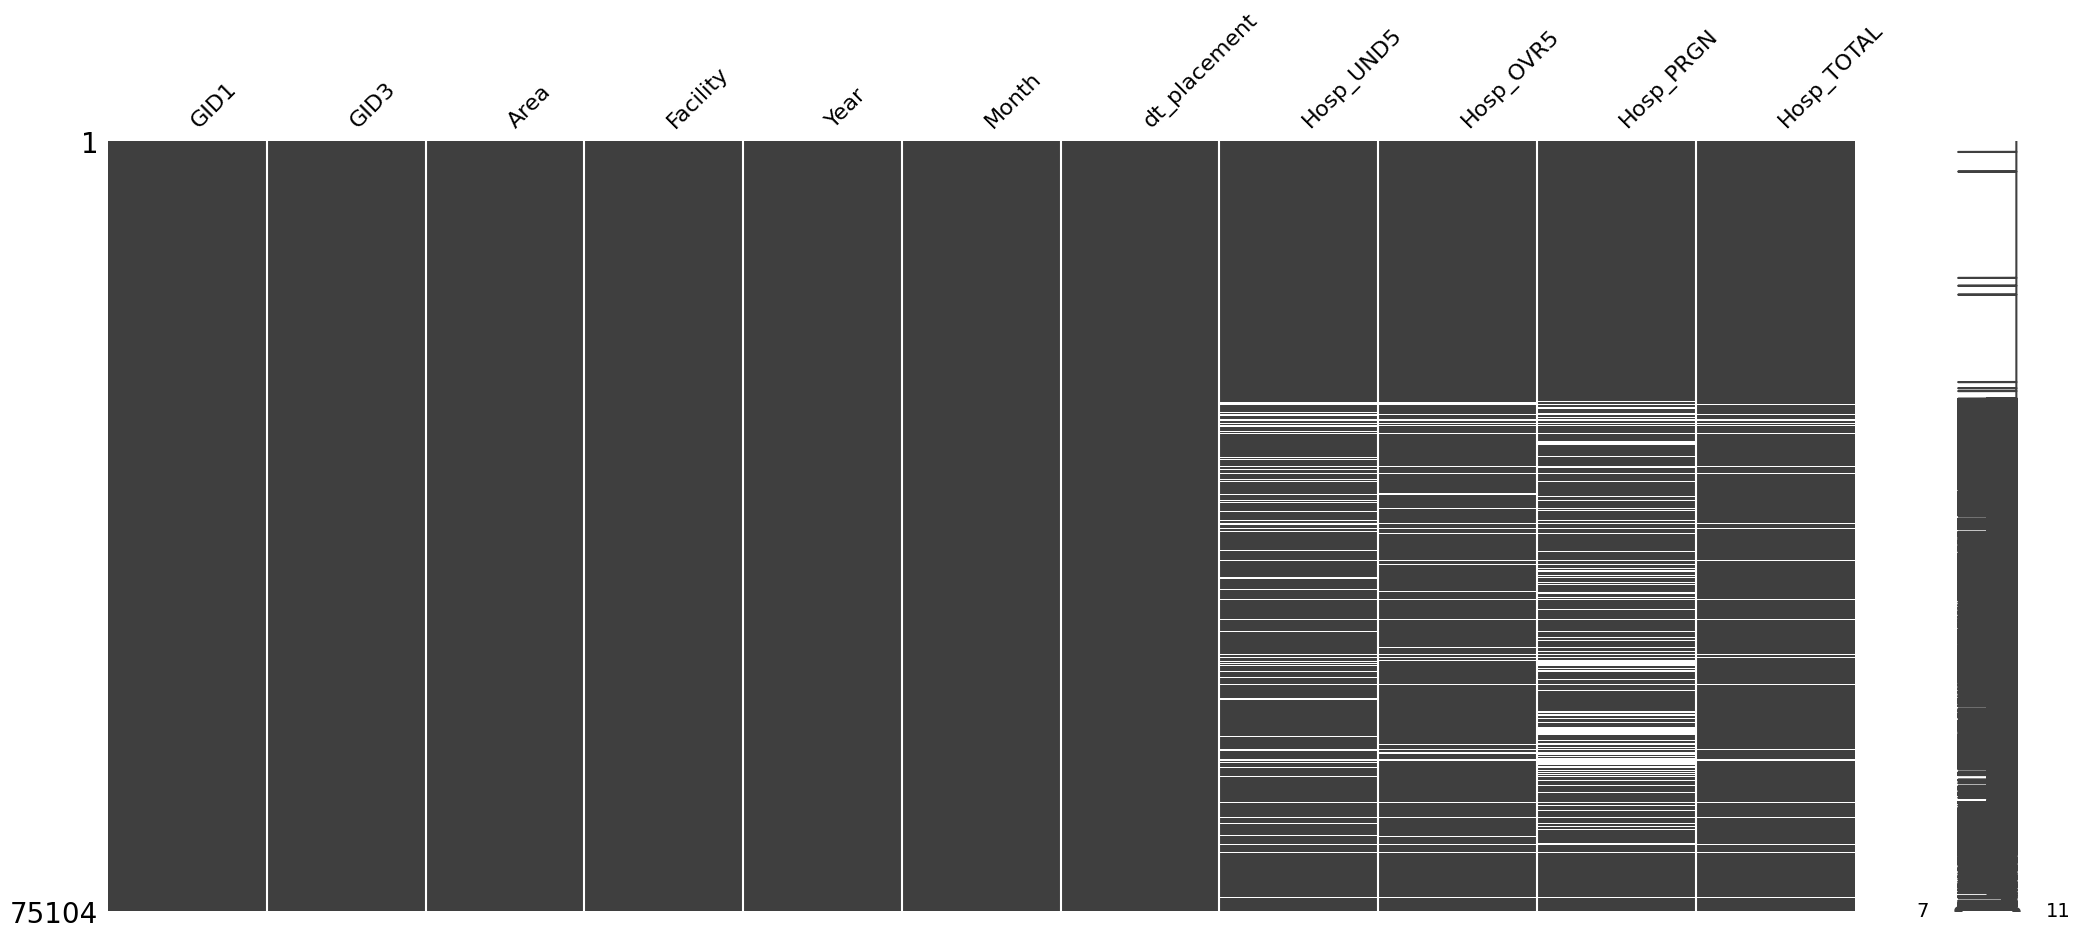

In [19]:
missingno.matrix(df_hospitalizations)

<Axes: >

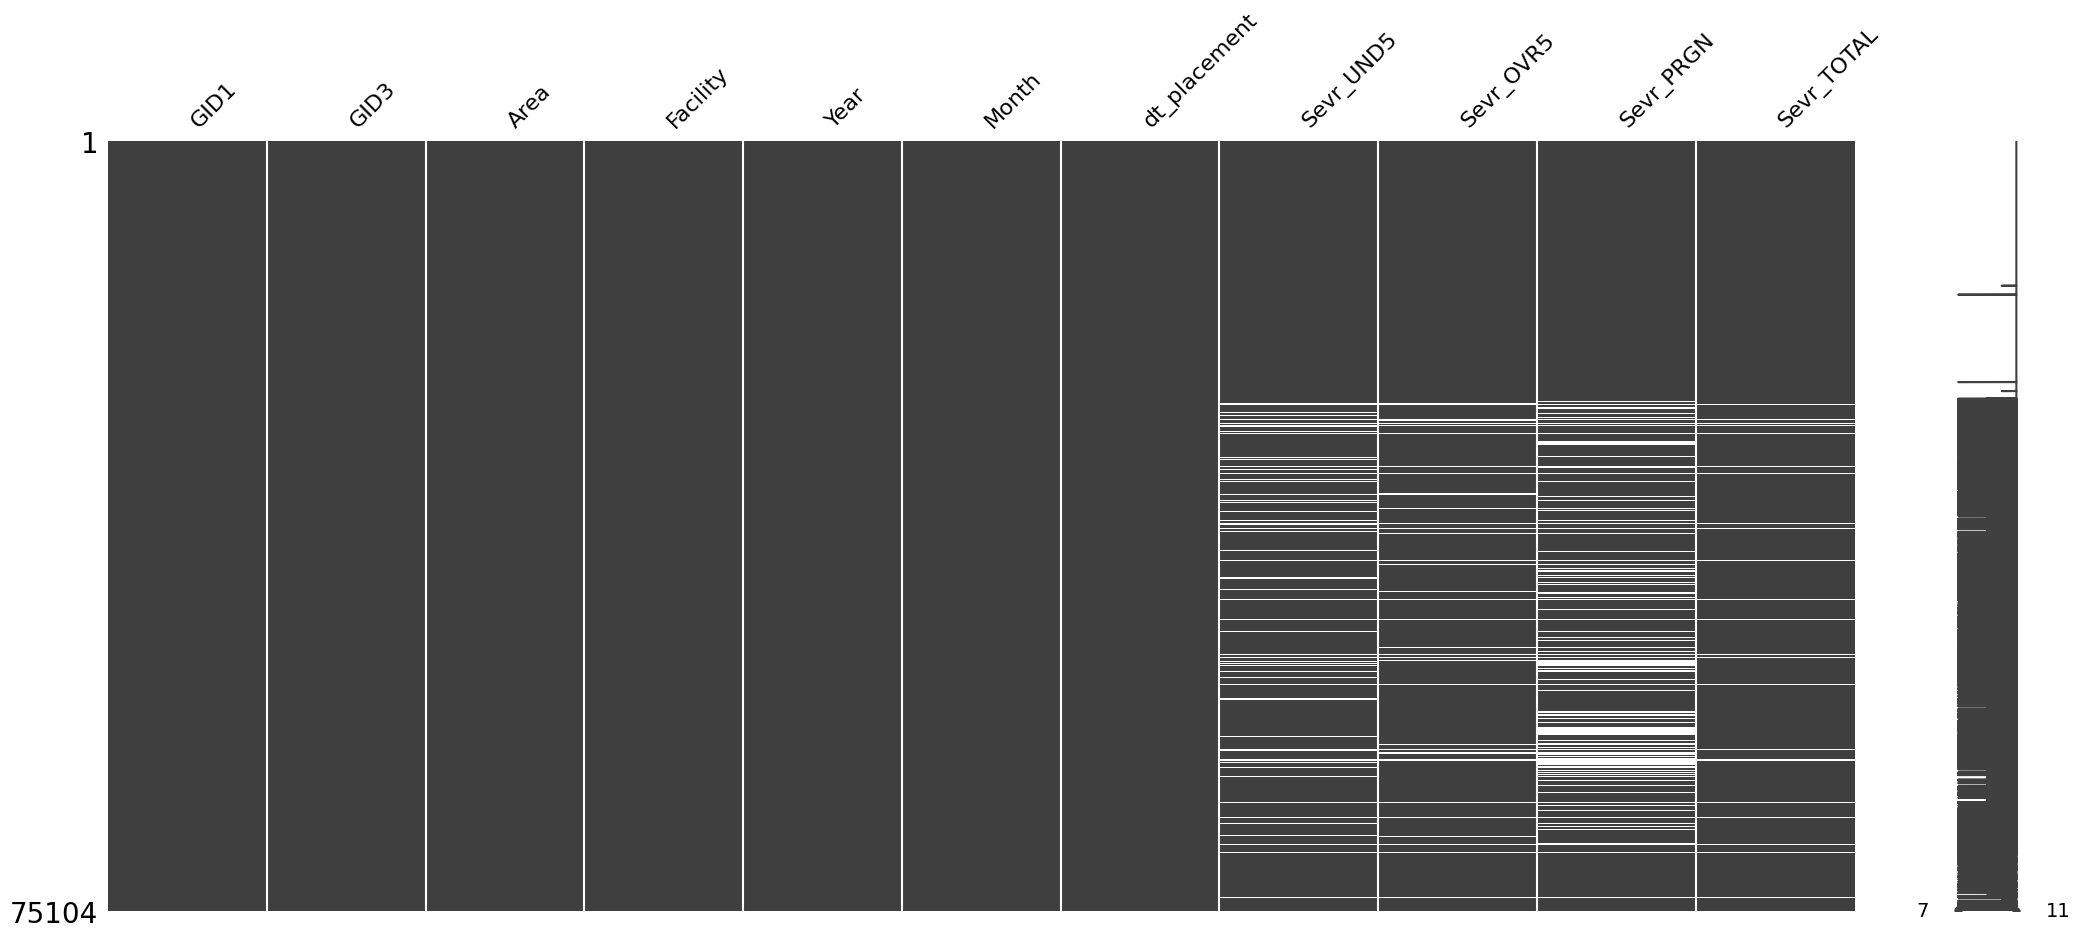

In [20]:
missingno.matrix(df_severe)

<Axes: >

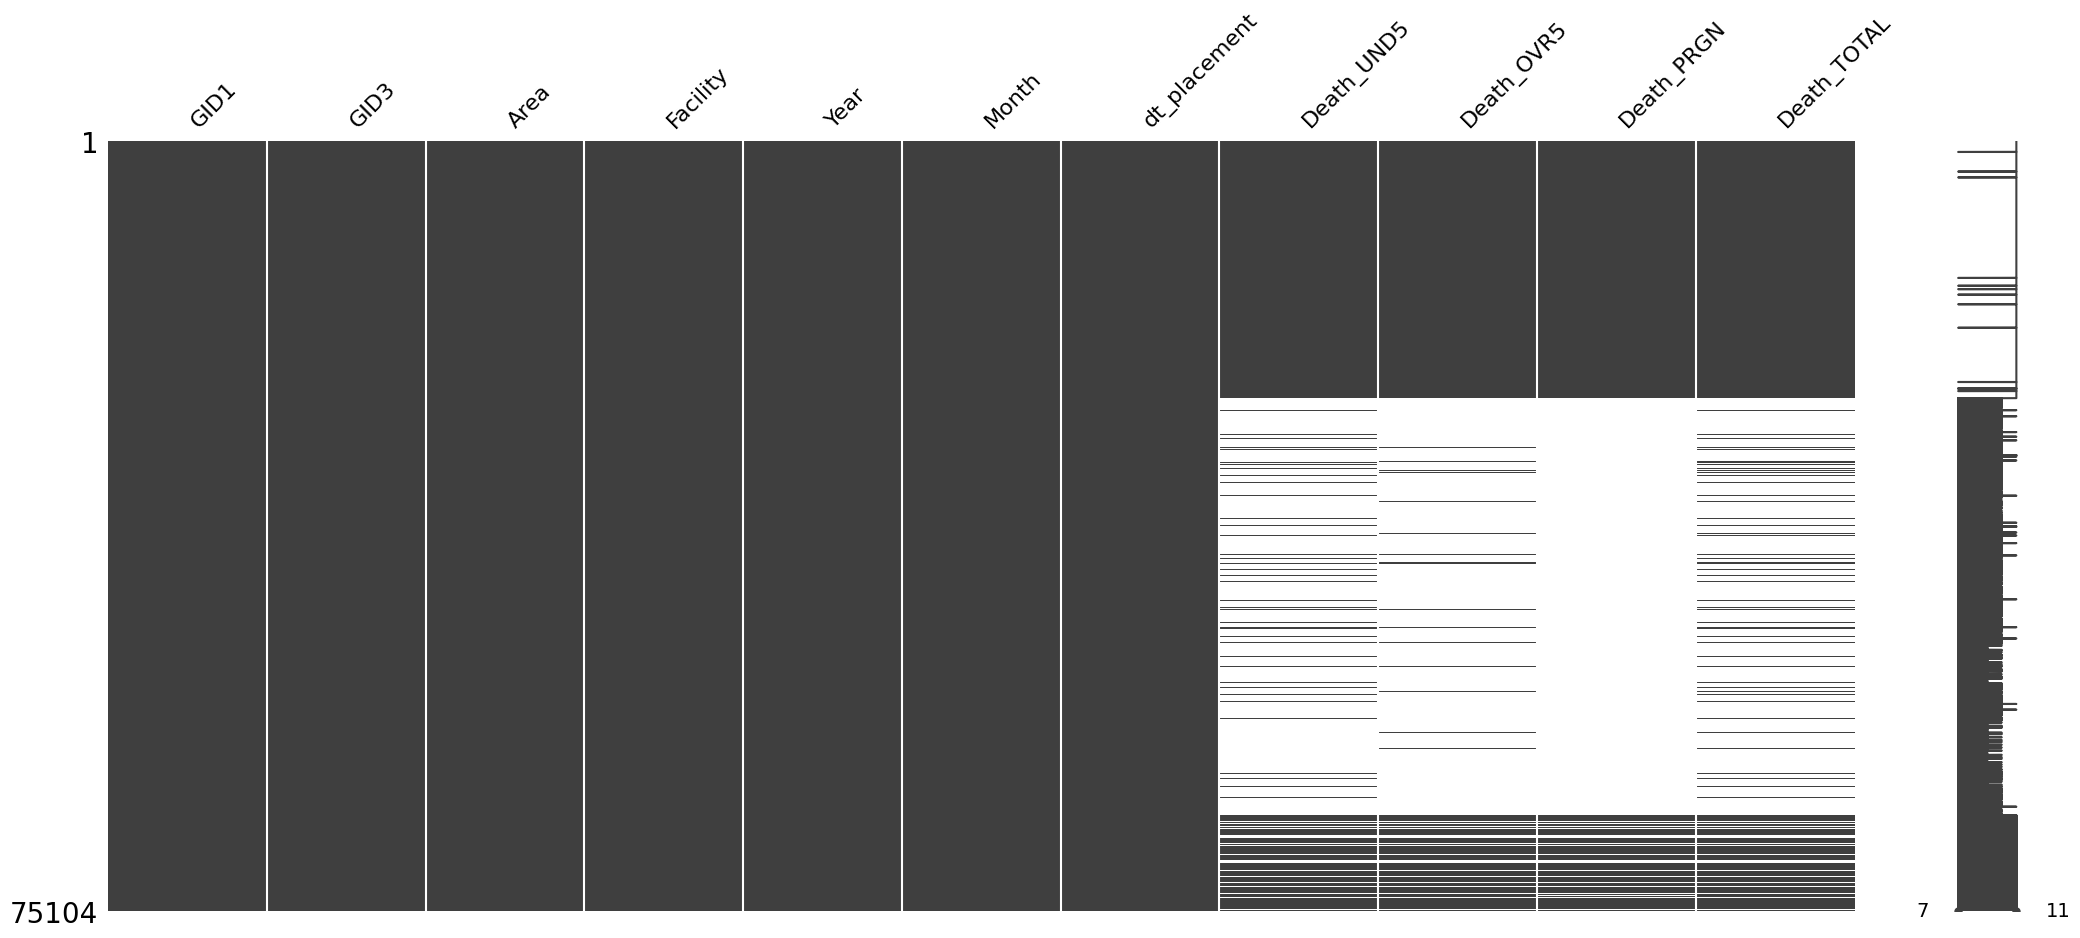

In [21]:
missingno.matrix(df_deaths)

<Axes: >

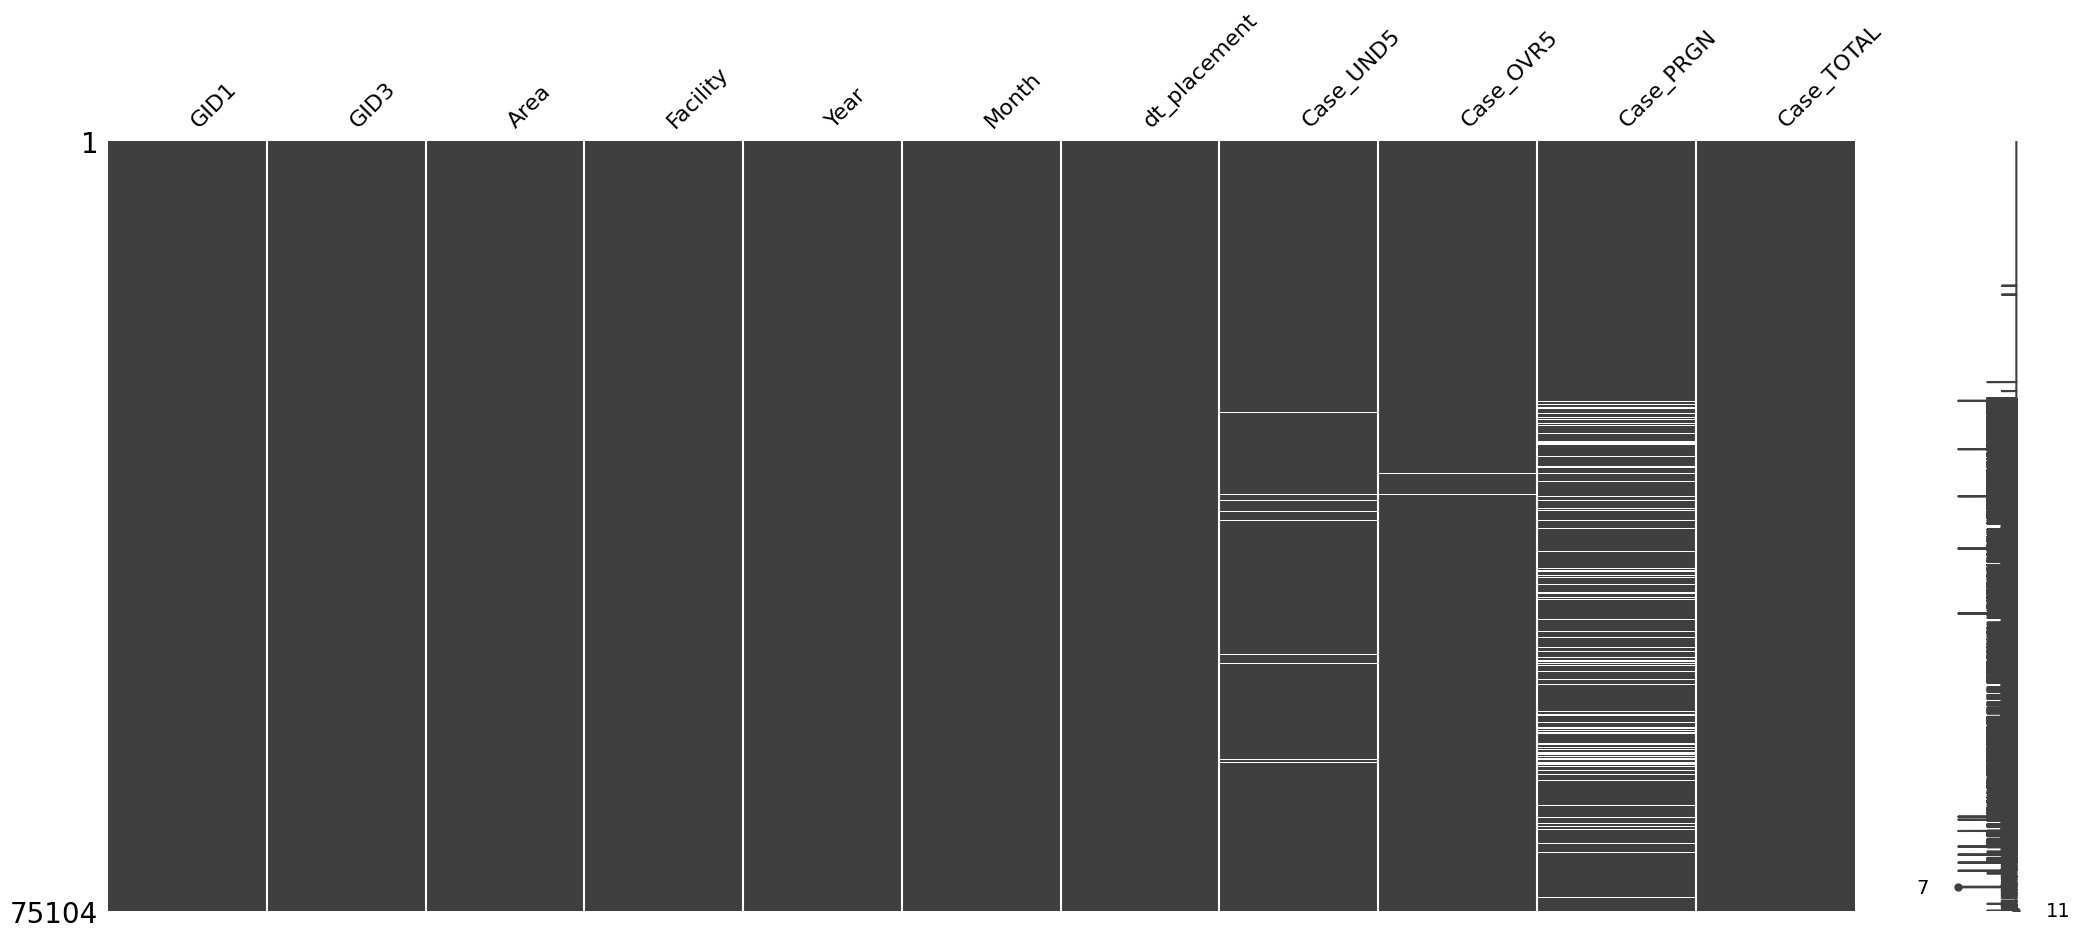

In [22]:
missingno.matrix(df_cases)

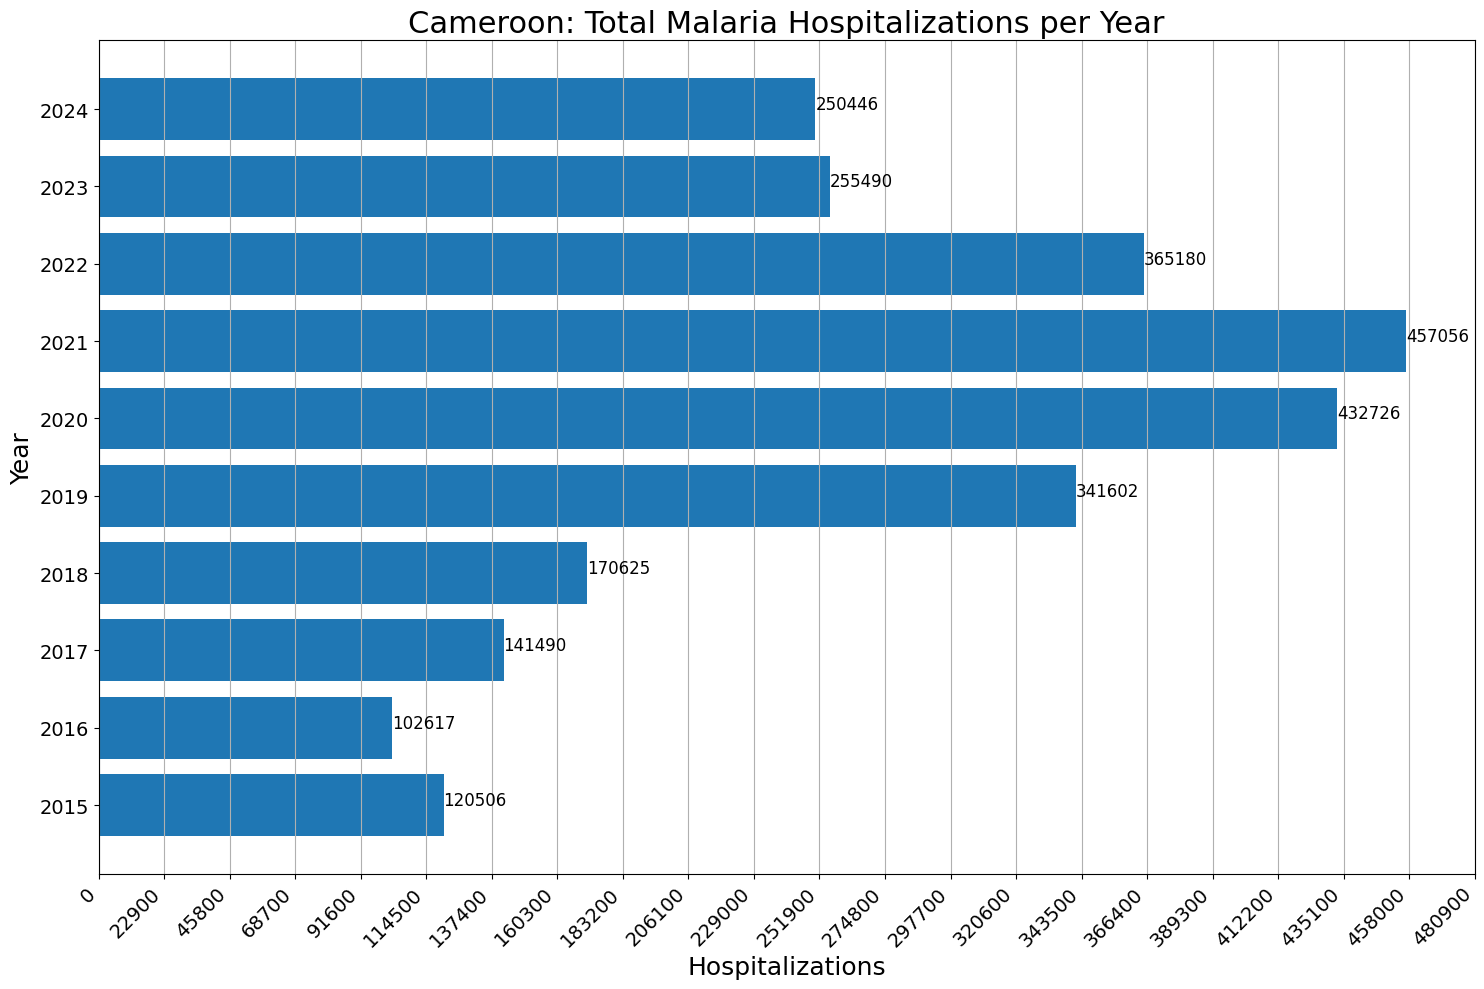

In [23]:
plot_grouped_barh(df_hospitalizations, group_col='Year', value_col='Hosp_TOTAL',
                          xlabel='Hospitalizations', ylabel='Year', title='Cameroon: Total Malaria Hospitalizations per Year')

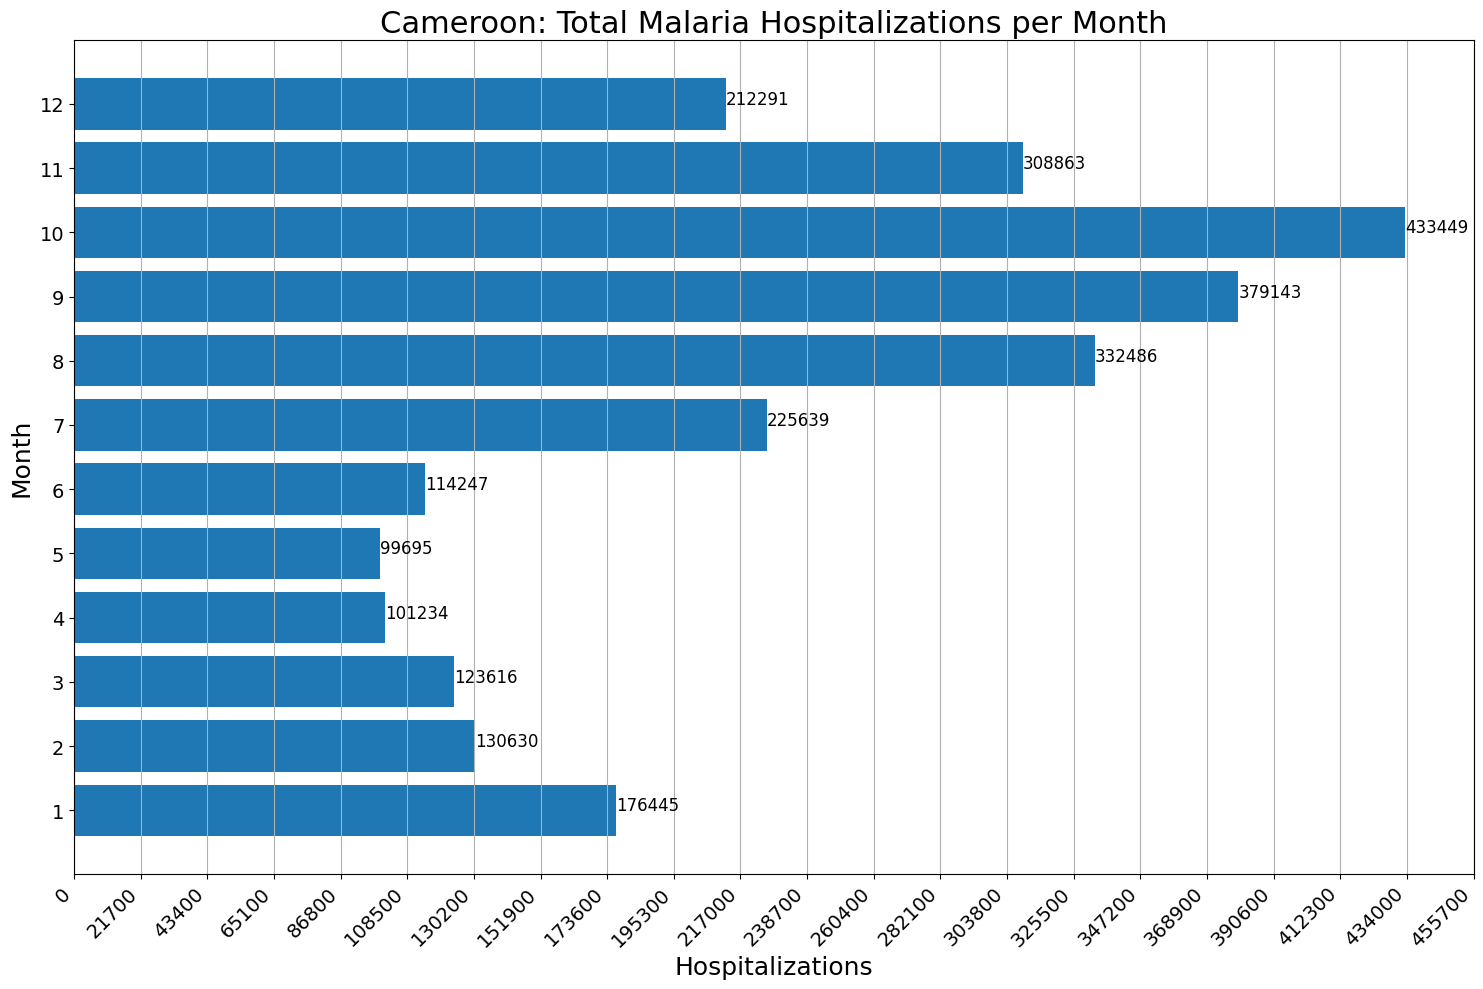

In [24]:
plot_grouped_barh(df_hospitalizations, group_col='Month', value_col='Hosp_TOTAL',
                          xlabel='Hospitalizations', ylabel='Month', title='Cameroon: Total Malaria Hospitalizations per Month')

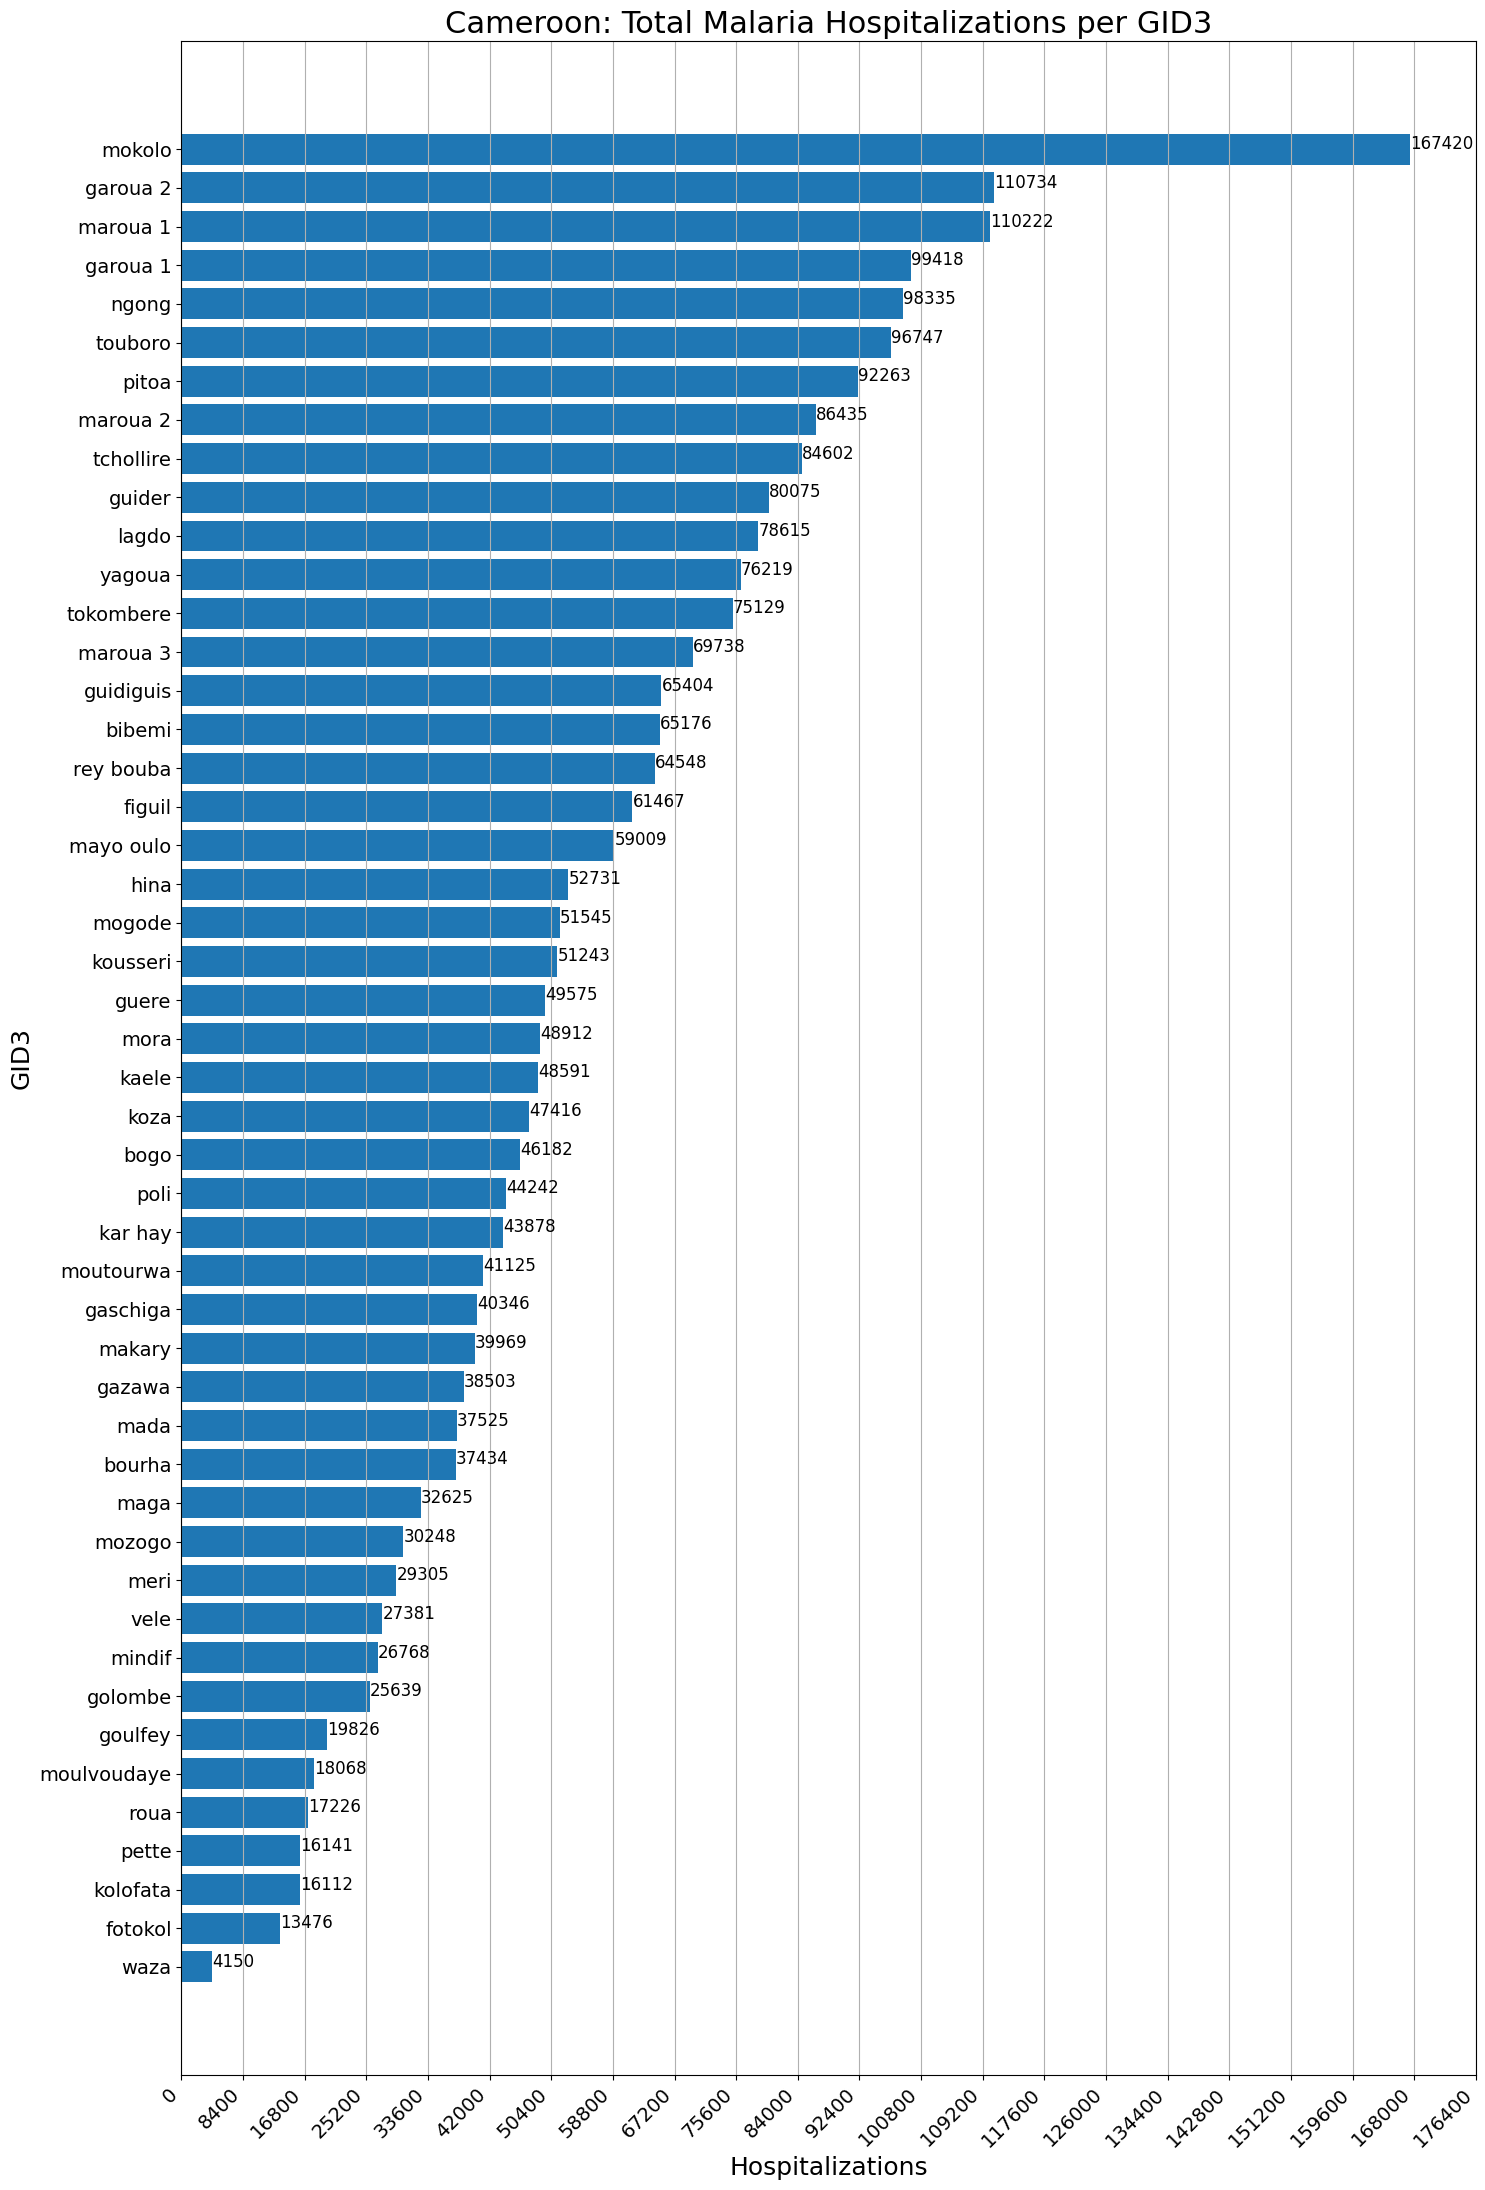

In [25]:
plot_grouped_barh(df_hospitalizations, group_col='GID3', value_col='Hosp_TOTAL',
                           xlabel='Hospitalizations', ylabel='GID3', title='Cameroon: Total Malaria Hospitalizations per GID3',
                           figsize=(15,22), text_size=12)

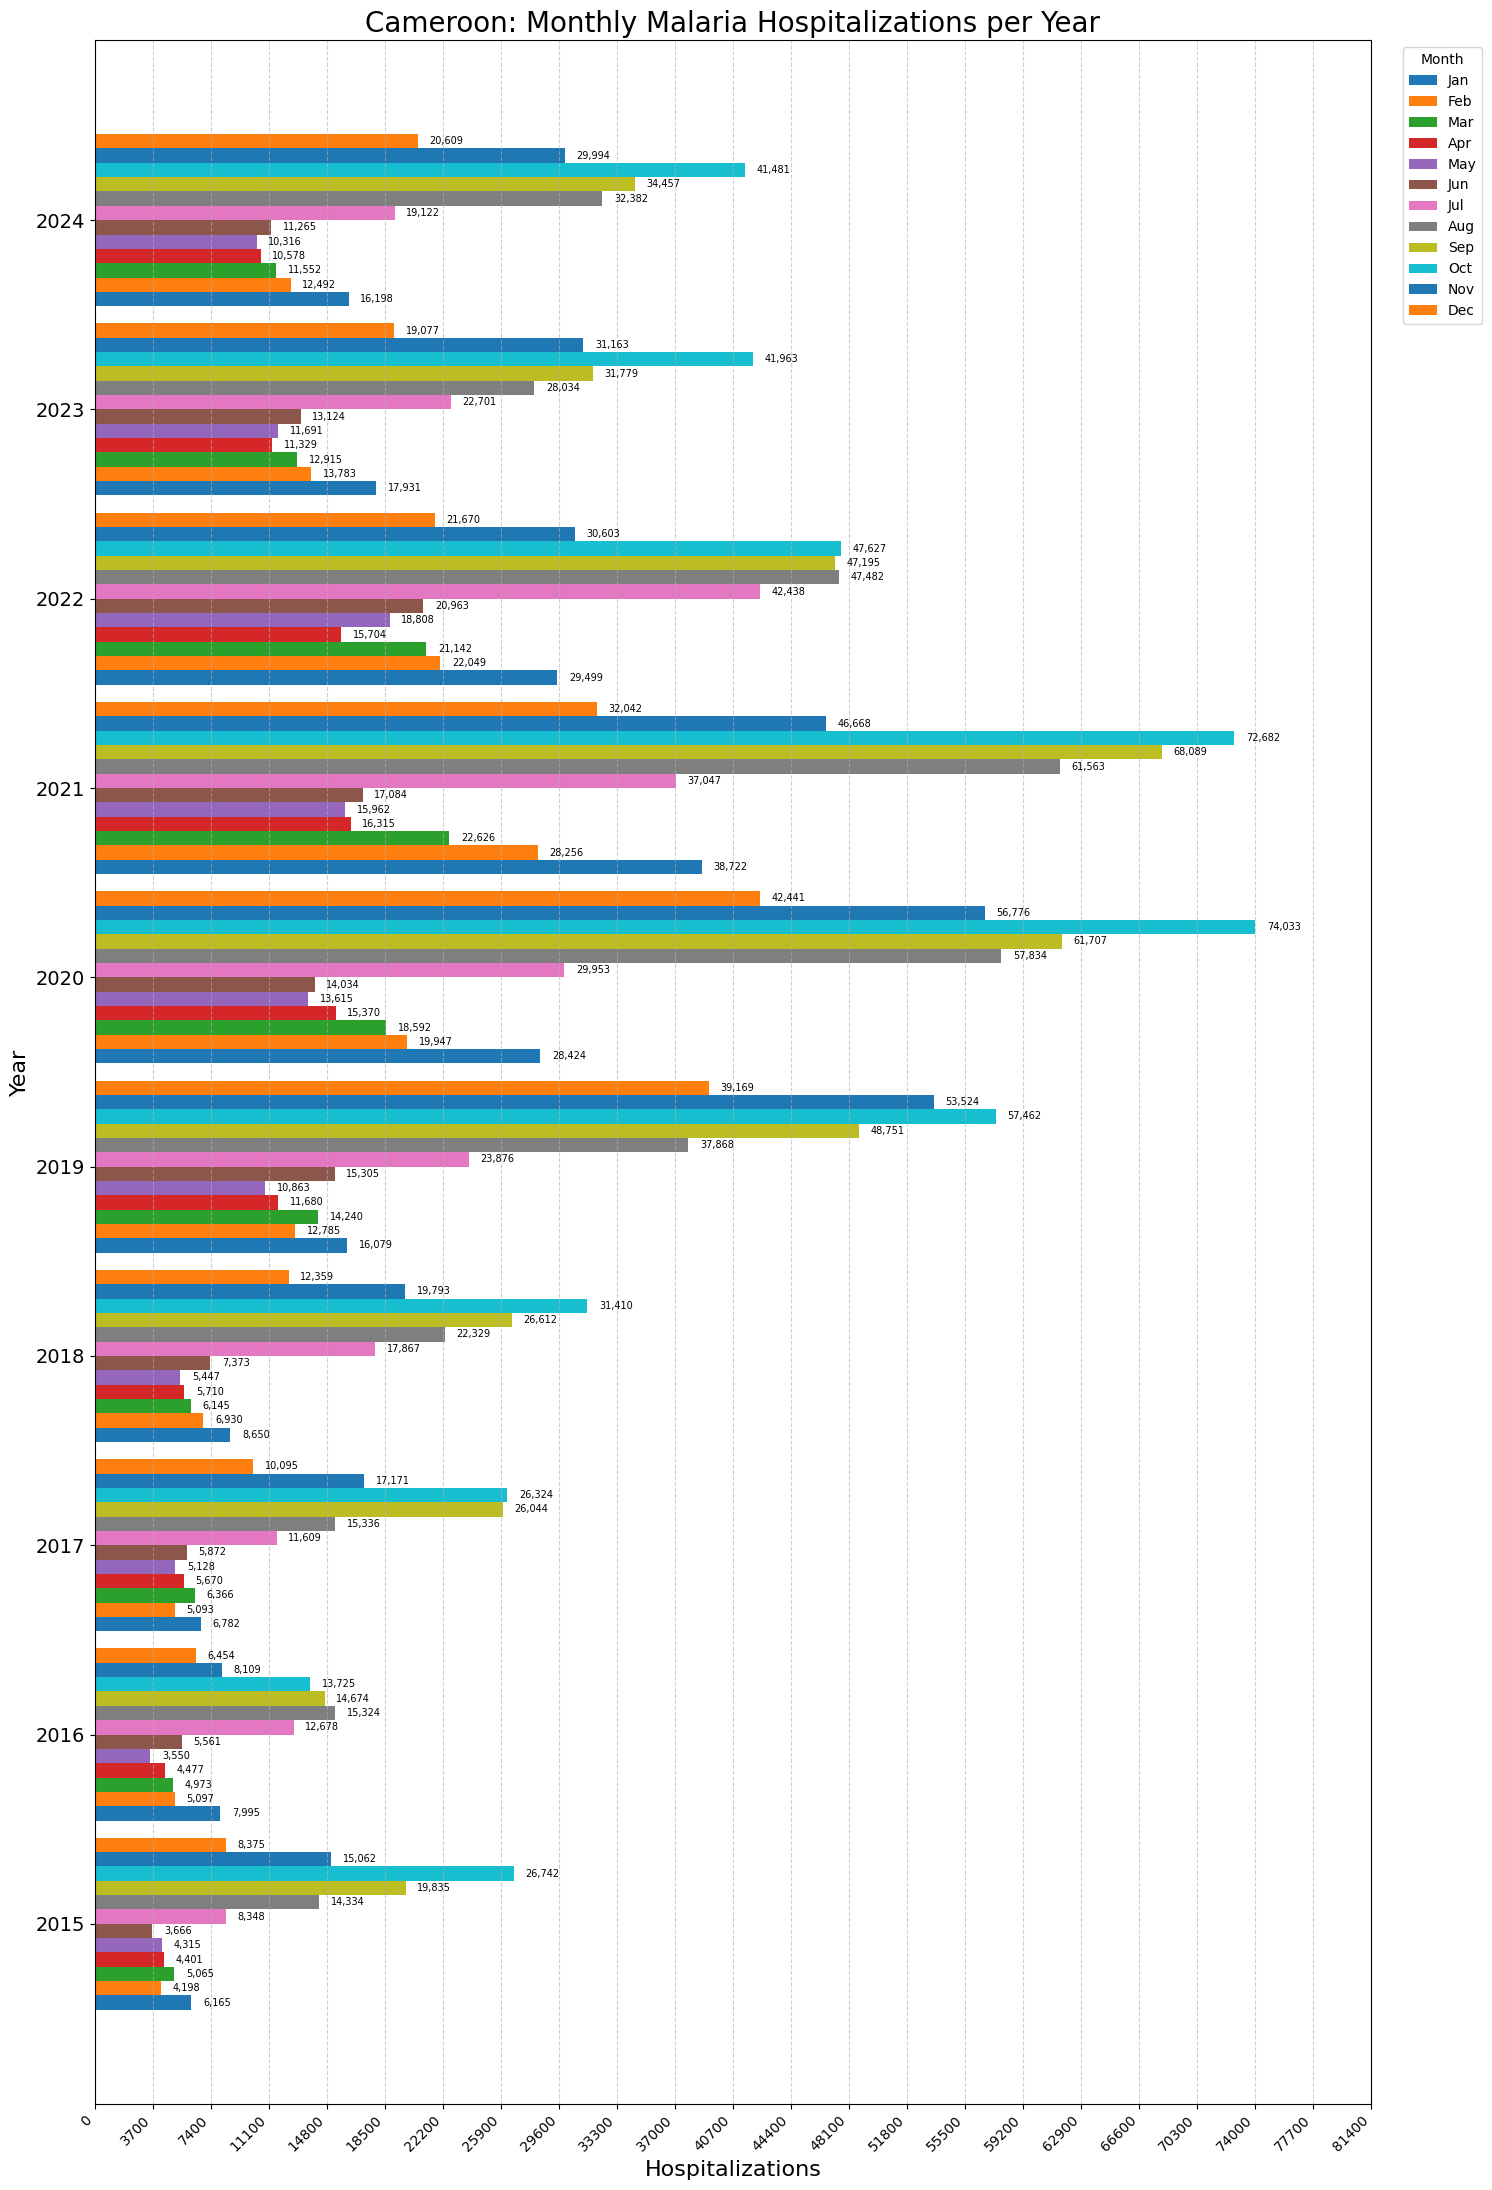

In [26]:
plot_monthly_yearly_horizontal_bars(df_hospitalizations, 'Hosp_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22),
                                    title='Cameroon: Monthly Malaria Hospitalizations per Year', xlabel='Hospitalizations')

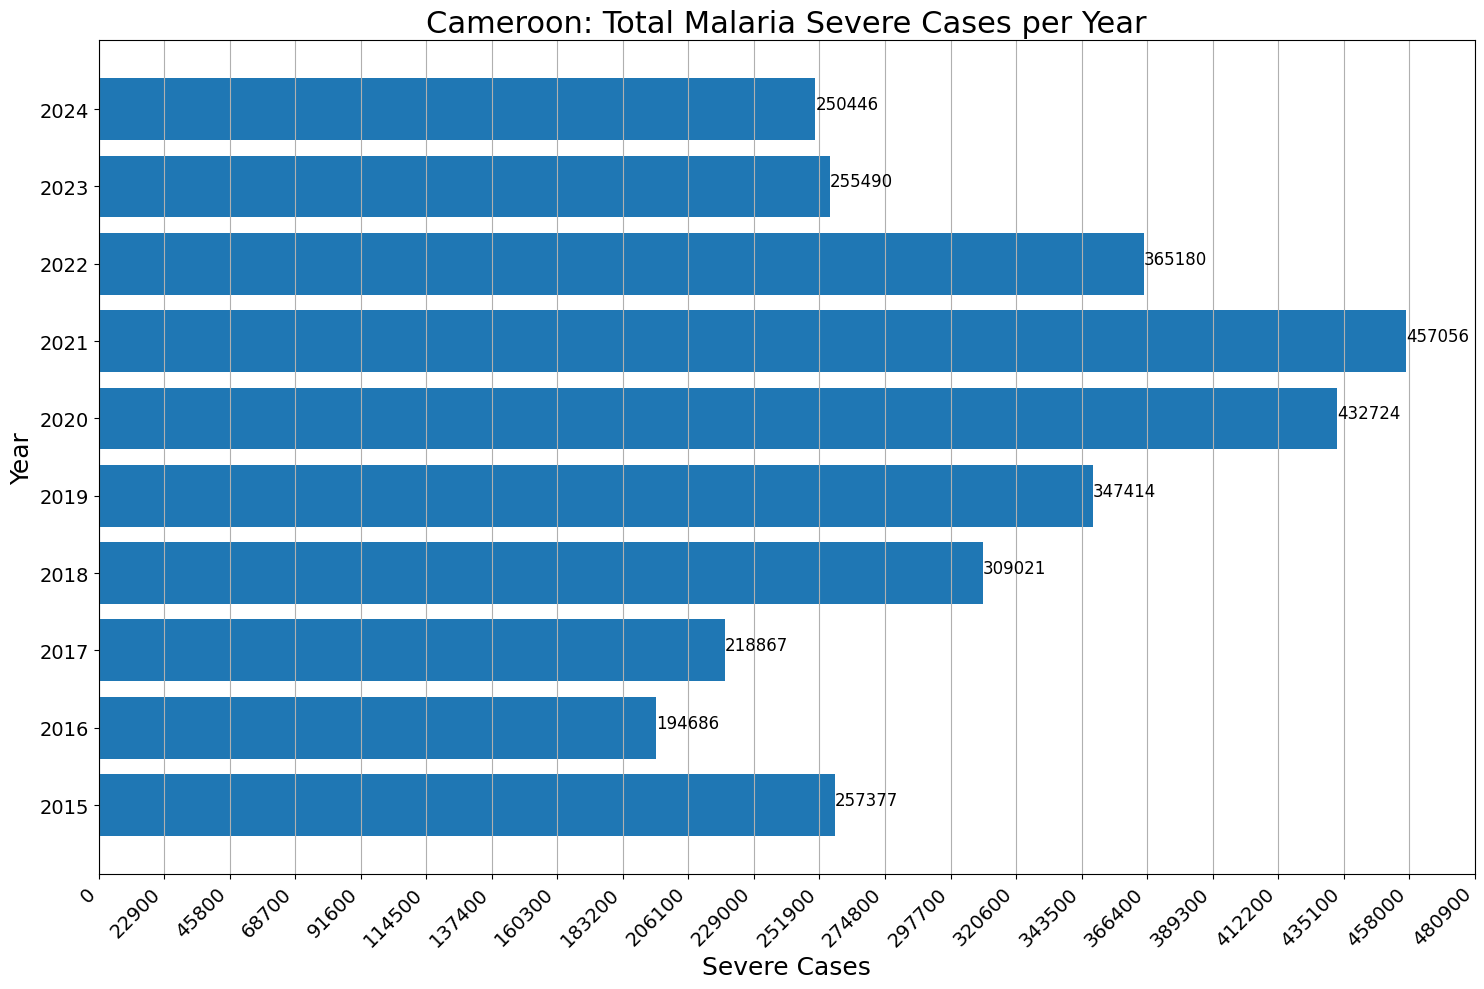

In [27]:
plot_grouped_barh(df_severe, group_col='Year', value_col='Sevr_TOTAL',
                          xlabel='Severe Cases', ylabel='Year', title='Cameroon: Total Malaria Severe Cases per Year')

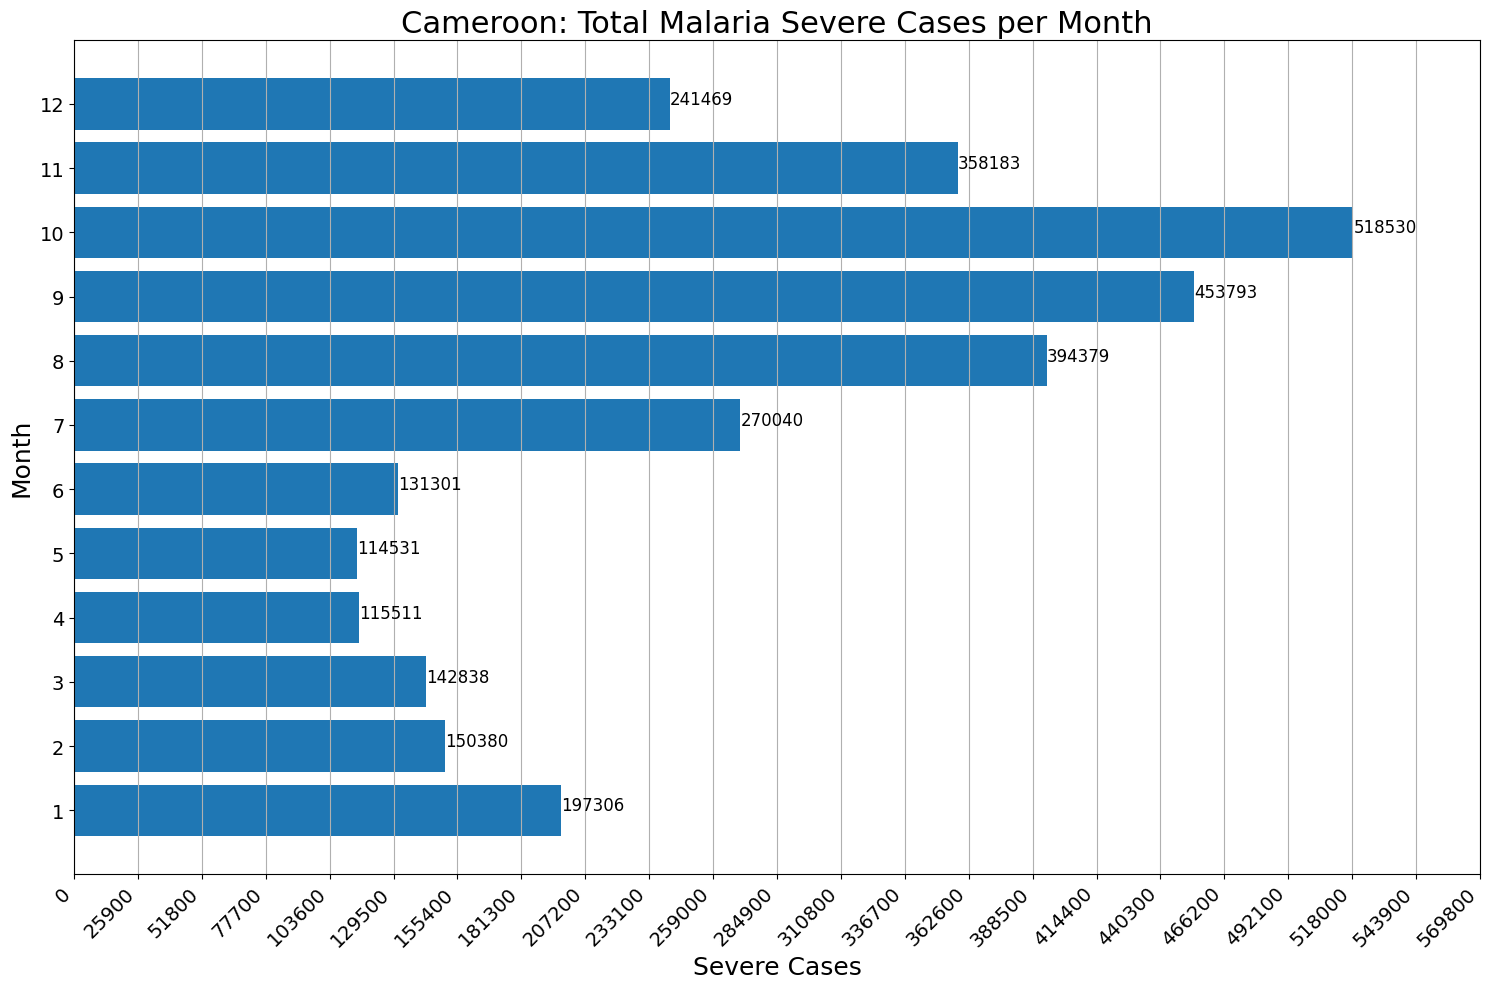

In [28]:
plot_grouped_barh(df_severe, group_col='Month', value_col='Sevr_TOTAL',
                          xlabel='Severe Cases', ylabel='Month', title='Cameroon: Total Malaria Severe Cases per Month')

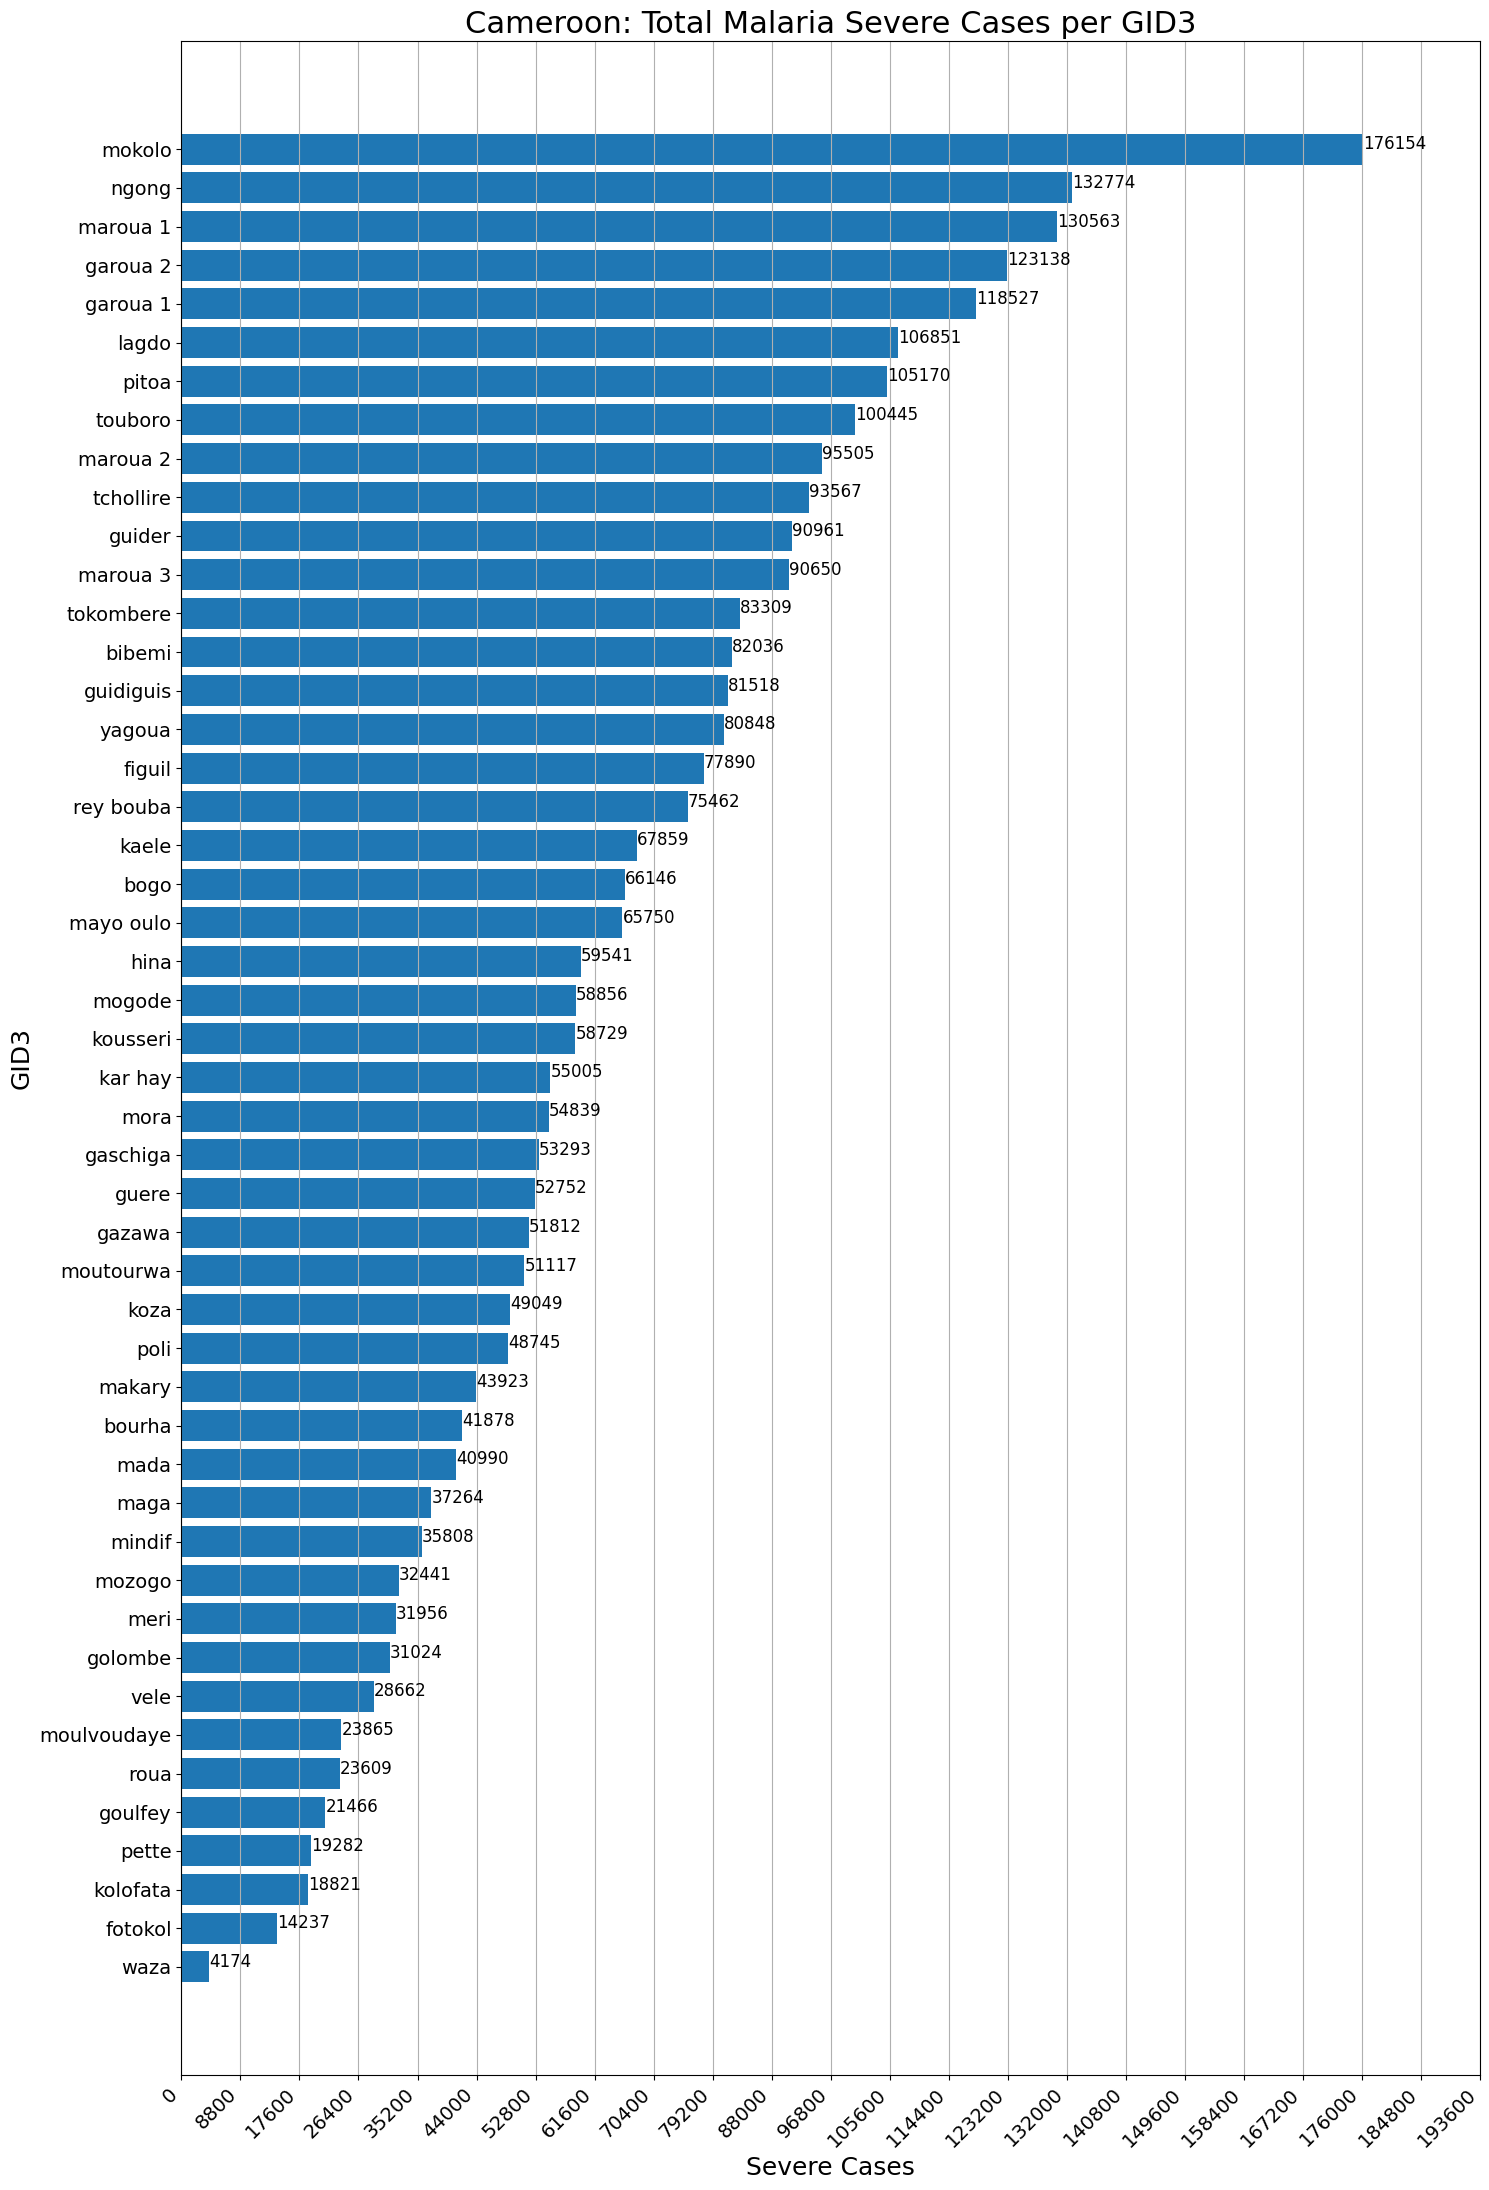

In [29]:
plot_grouped_barh(df_severe, group_col='GID3', value_col='Sevr_TOTAL',
                           xlabel='Severe Cases', ylabel='GID3', title='Cameroon: Total Malaria Severe Cases per GID3',
                           figsize=(15,22), text_size=12)

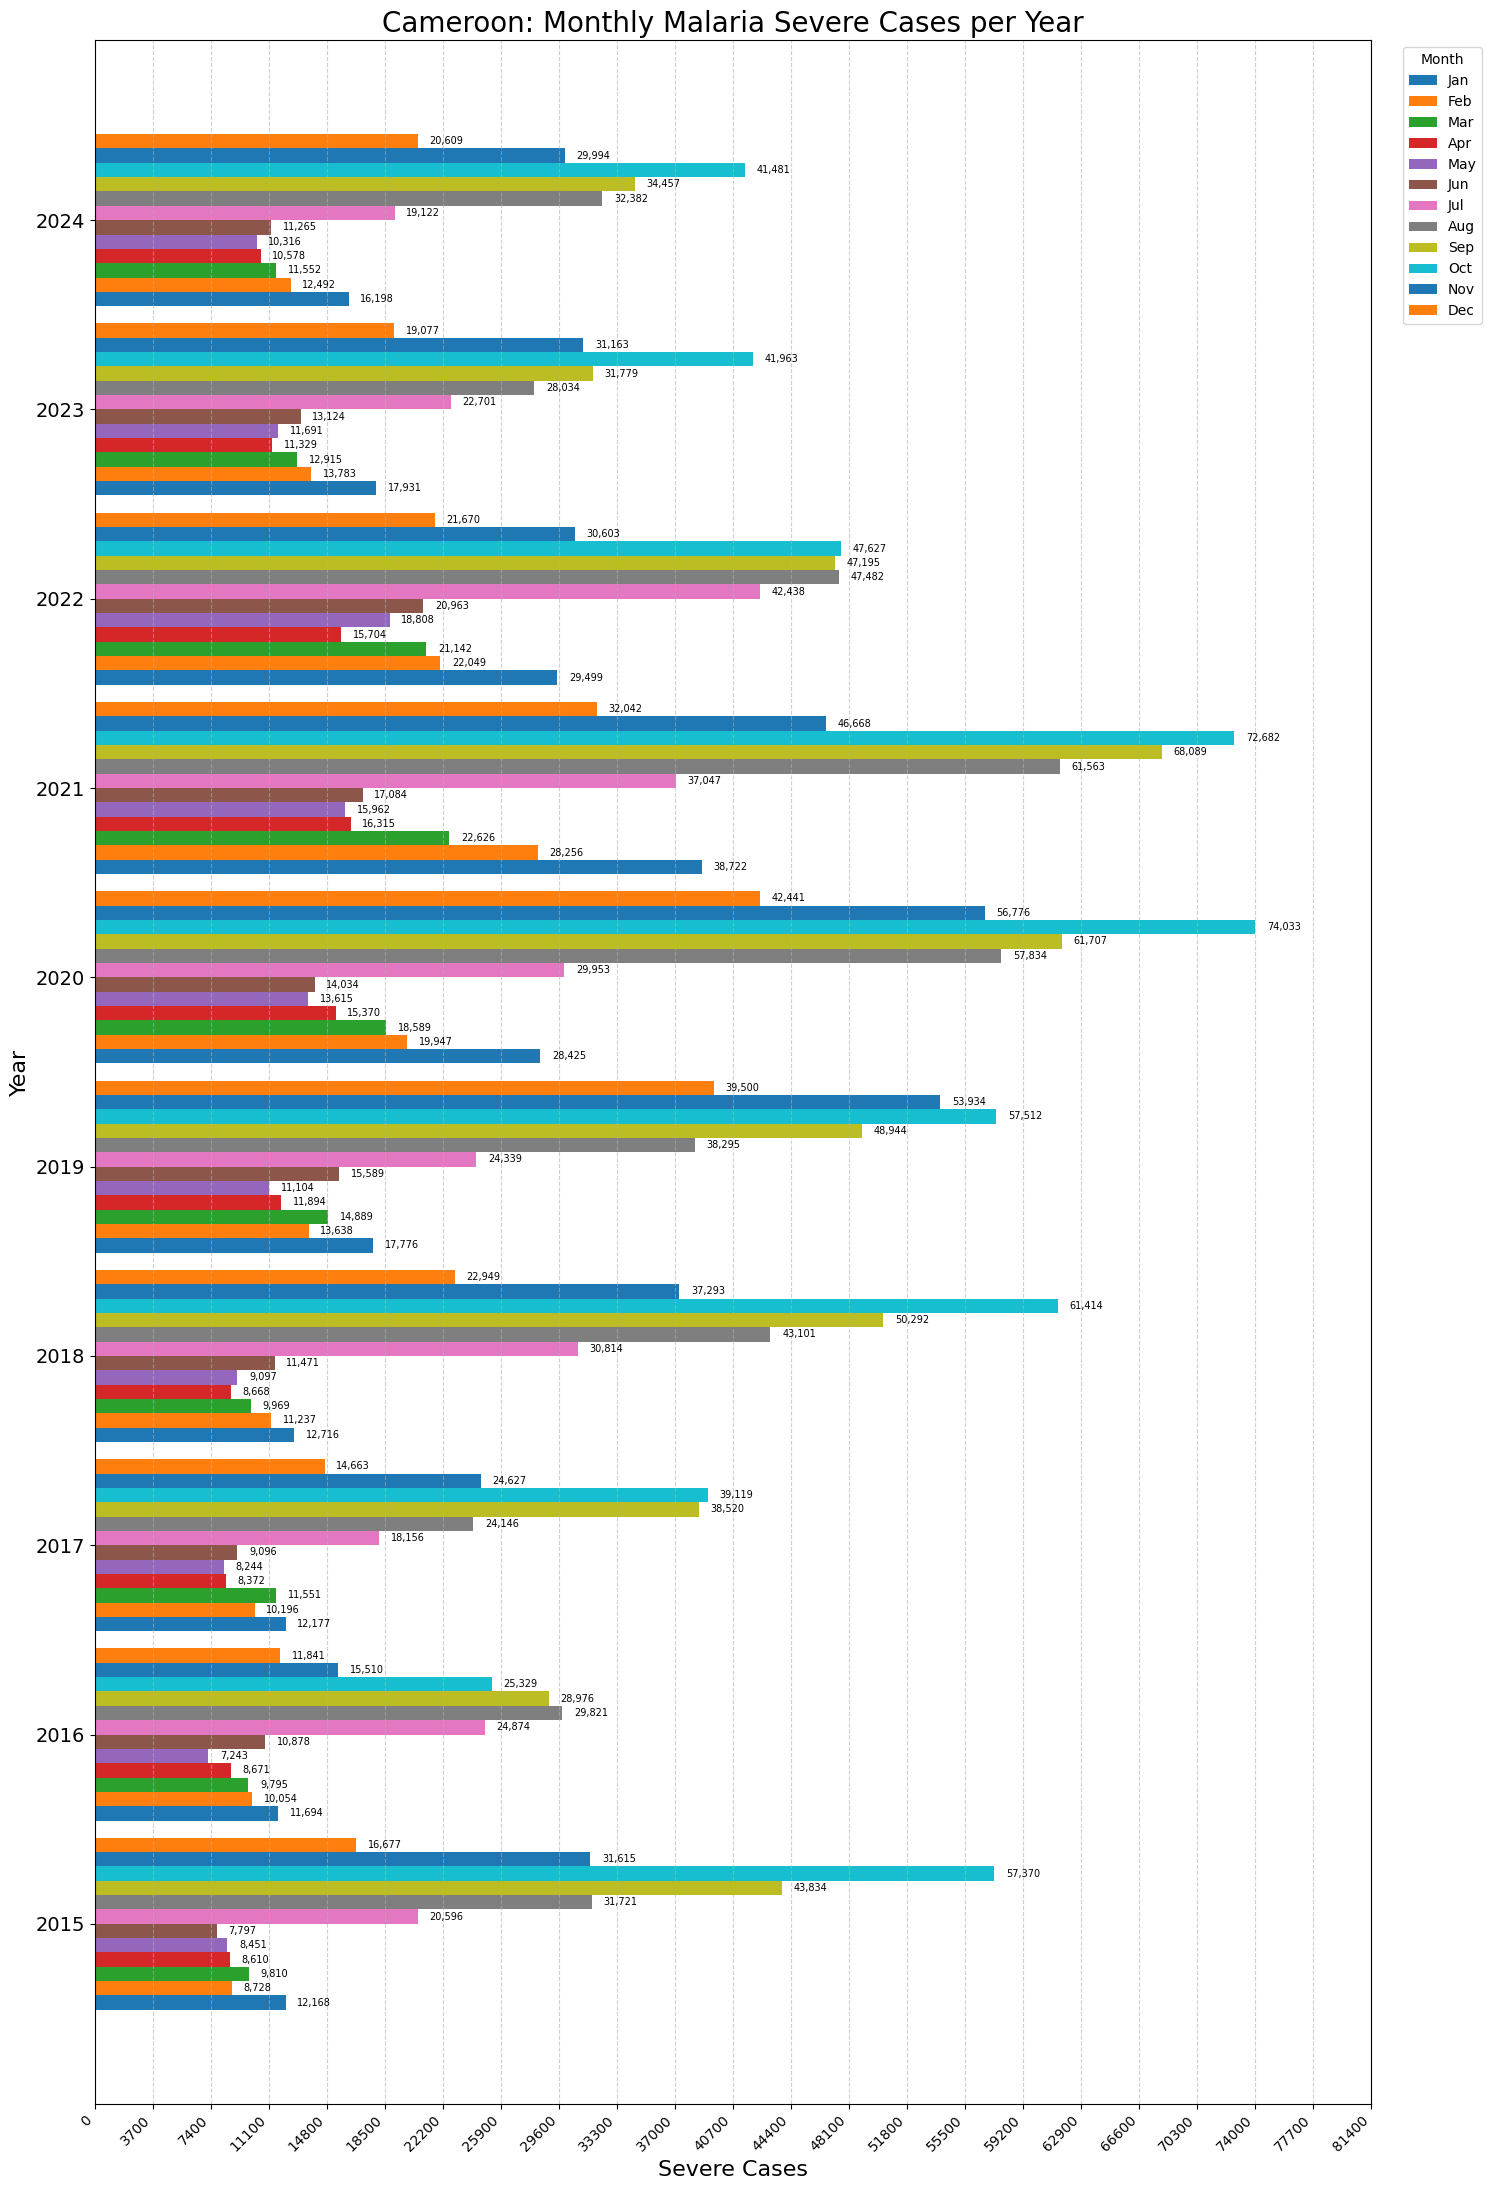

In [30]:
plot_monthly_yearly_horizontal_bars(df_severe, 'Sevr_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22),
                                    title='Cameroon: Monthly Malaria Severe Cases per Year', xlabel='Severe Cases')

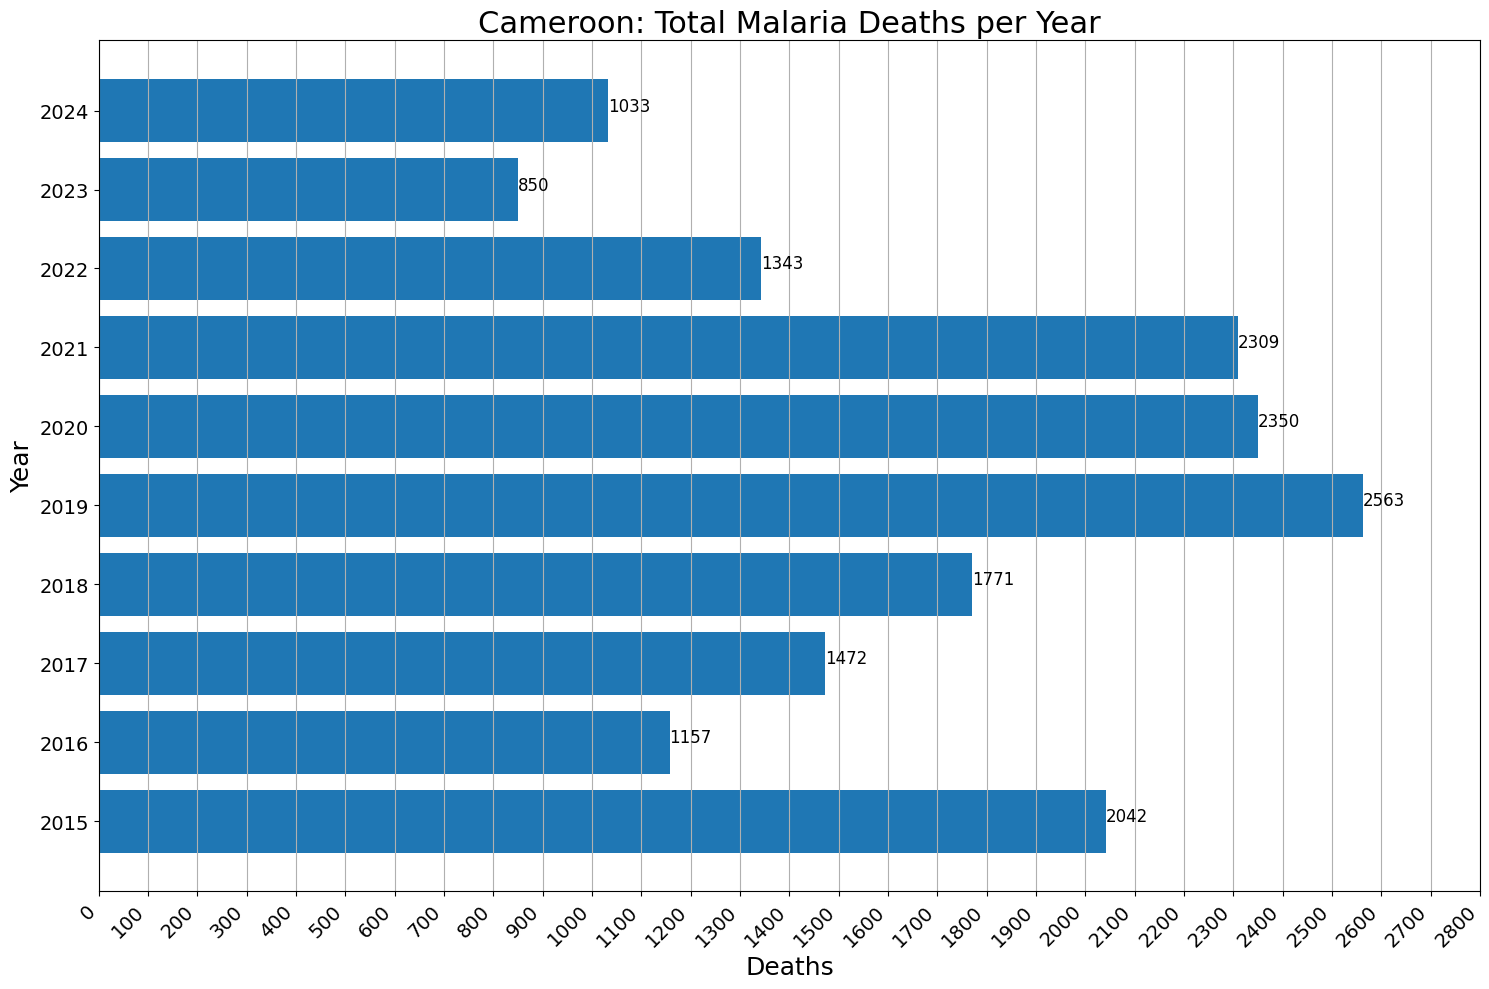

In [31]:
plot_grouped_barh(df_deaths, group_col='Year', value_col='Death_TOTAL',
                          xlabel='Deaths', ylabel='Year', title='Cameroon: Total Malaria Deaths per Year')

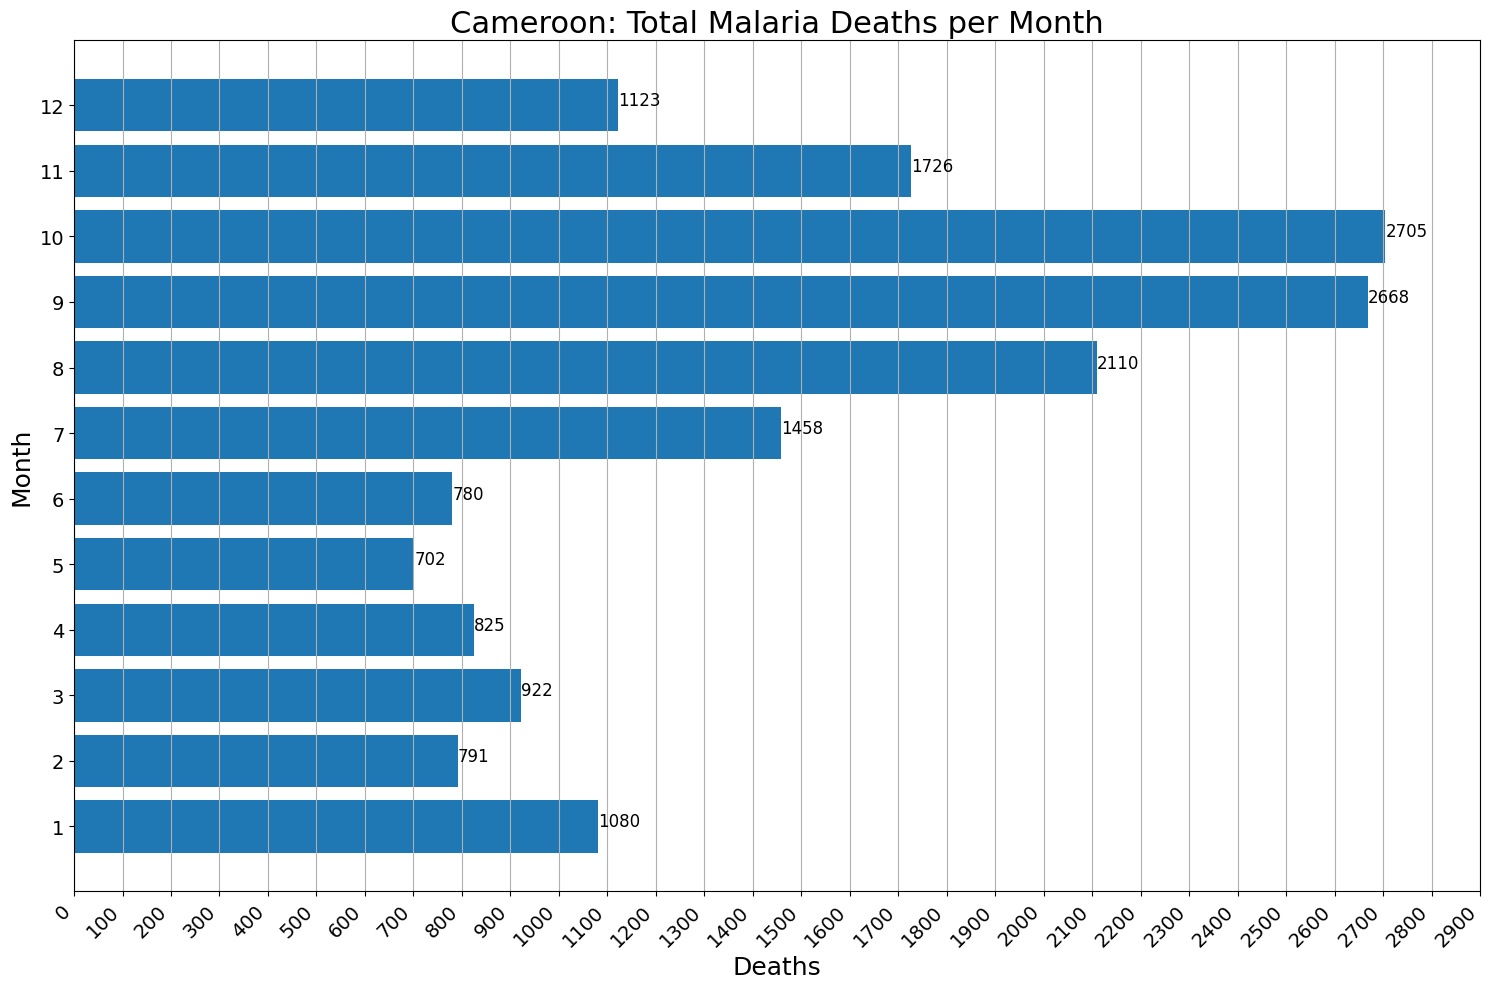

In [32]:
plot_grouped_barh(df_deaths, group_col='Month', value_col='Death_TOTAL',
                          xlabel='Deaths', ylabel='Month', title='Cameroon: Total Malaria Deaths per Month')

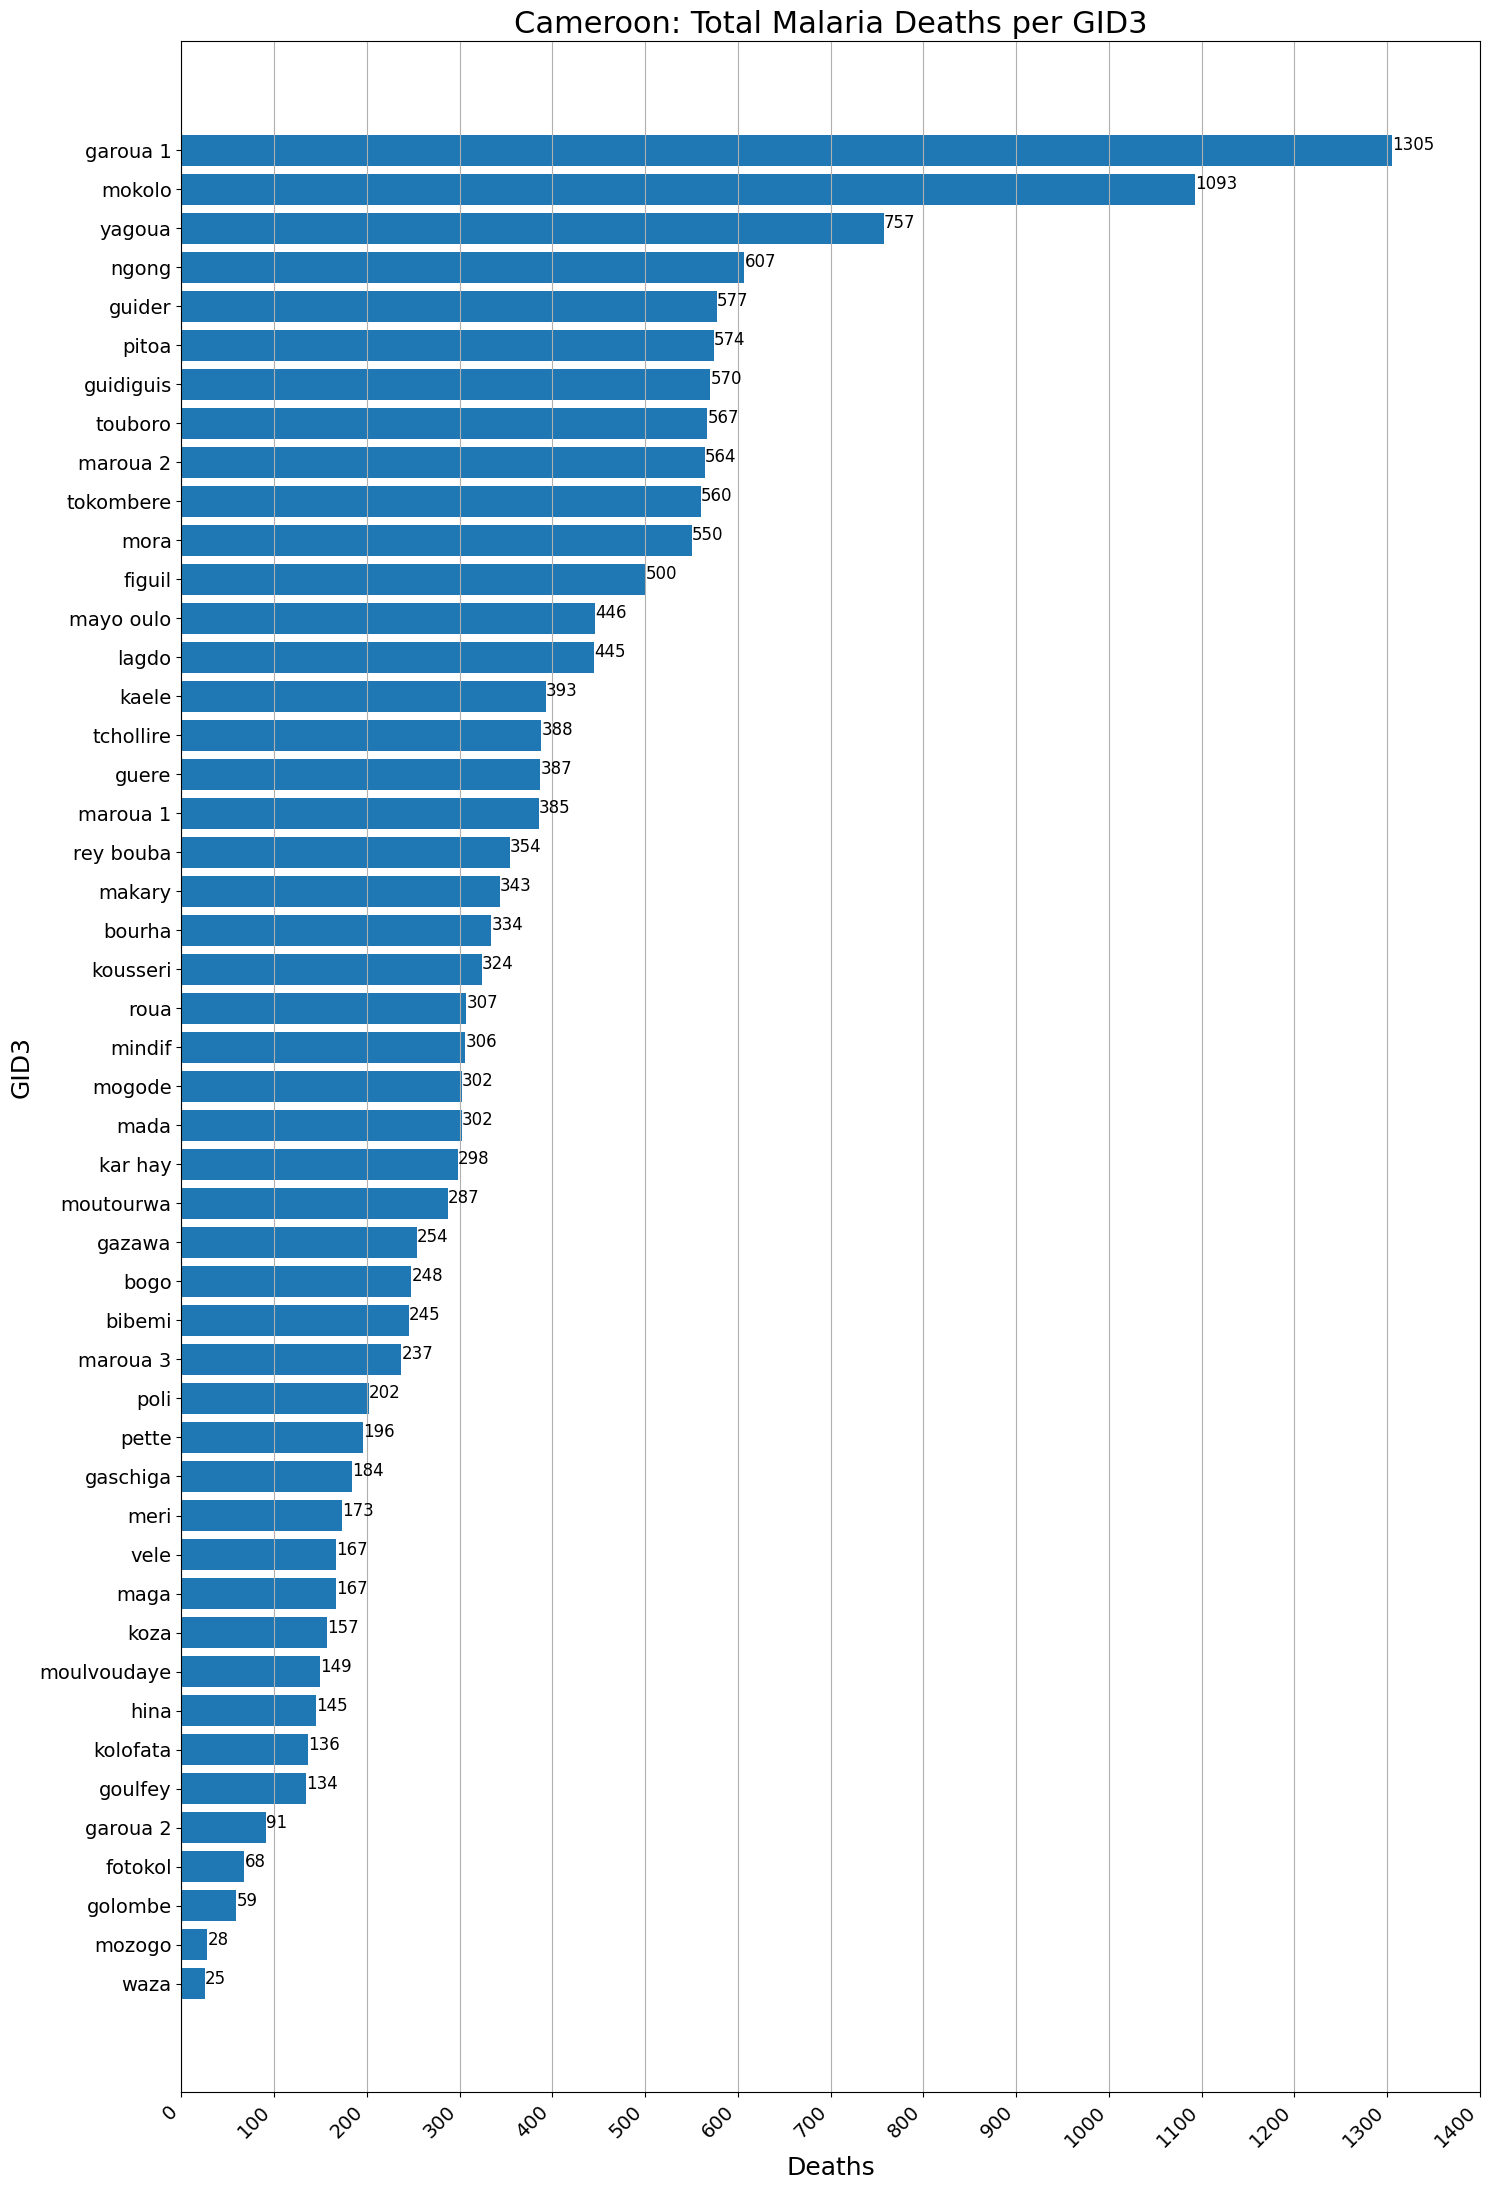

In [33]:
plot_grouped_barh(df_deaths, group_col='GID3', value_col='Death_TOTAL',
                           xlabel='Deaths', ylabel='GID3', title='Cameroon: Total Malaria Deaths per GID3',
                           figsize=(15,22), text_size=12)

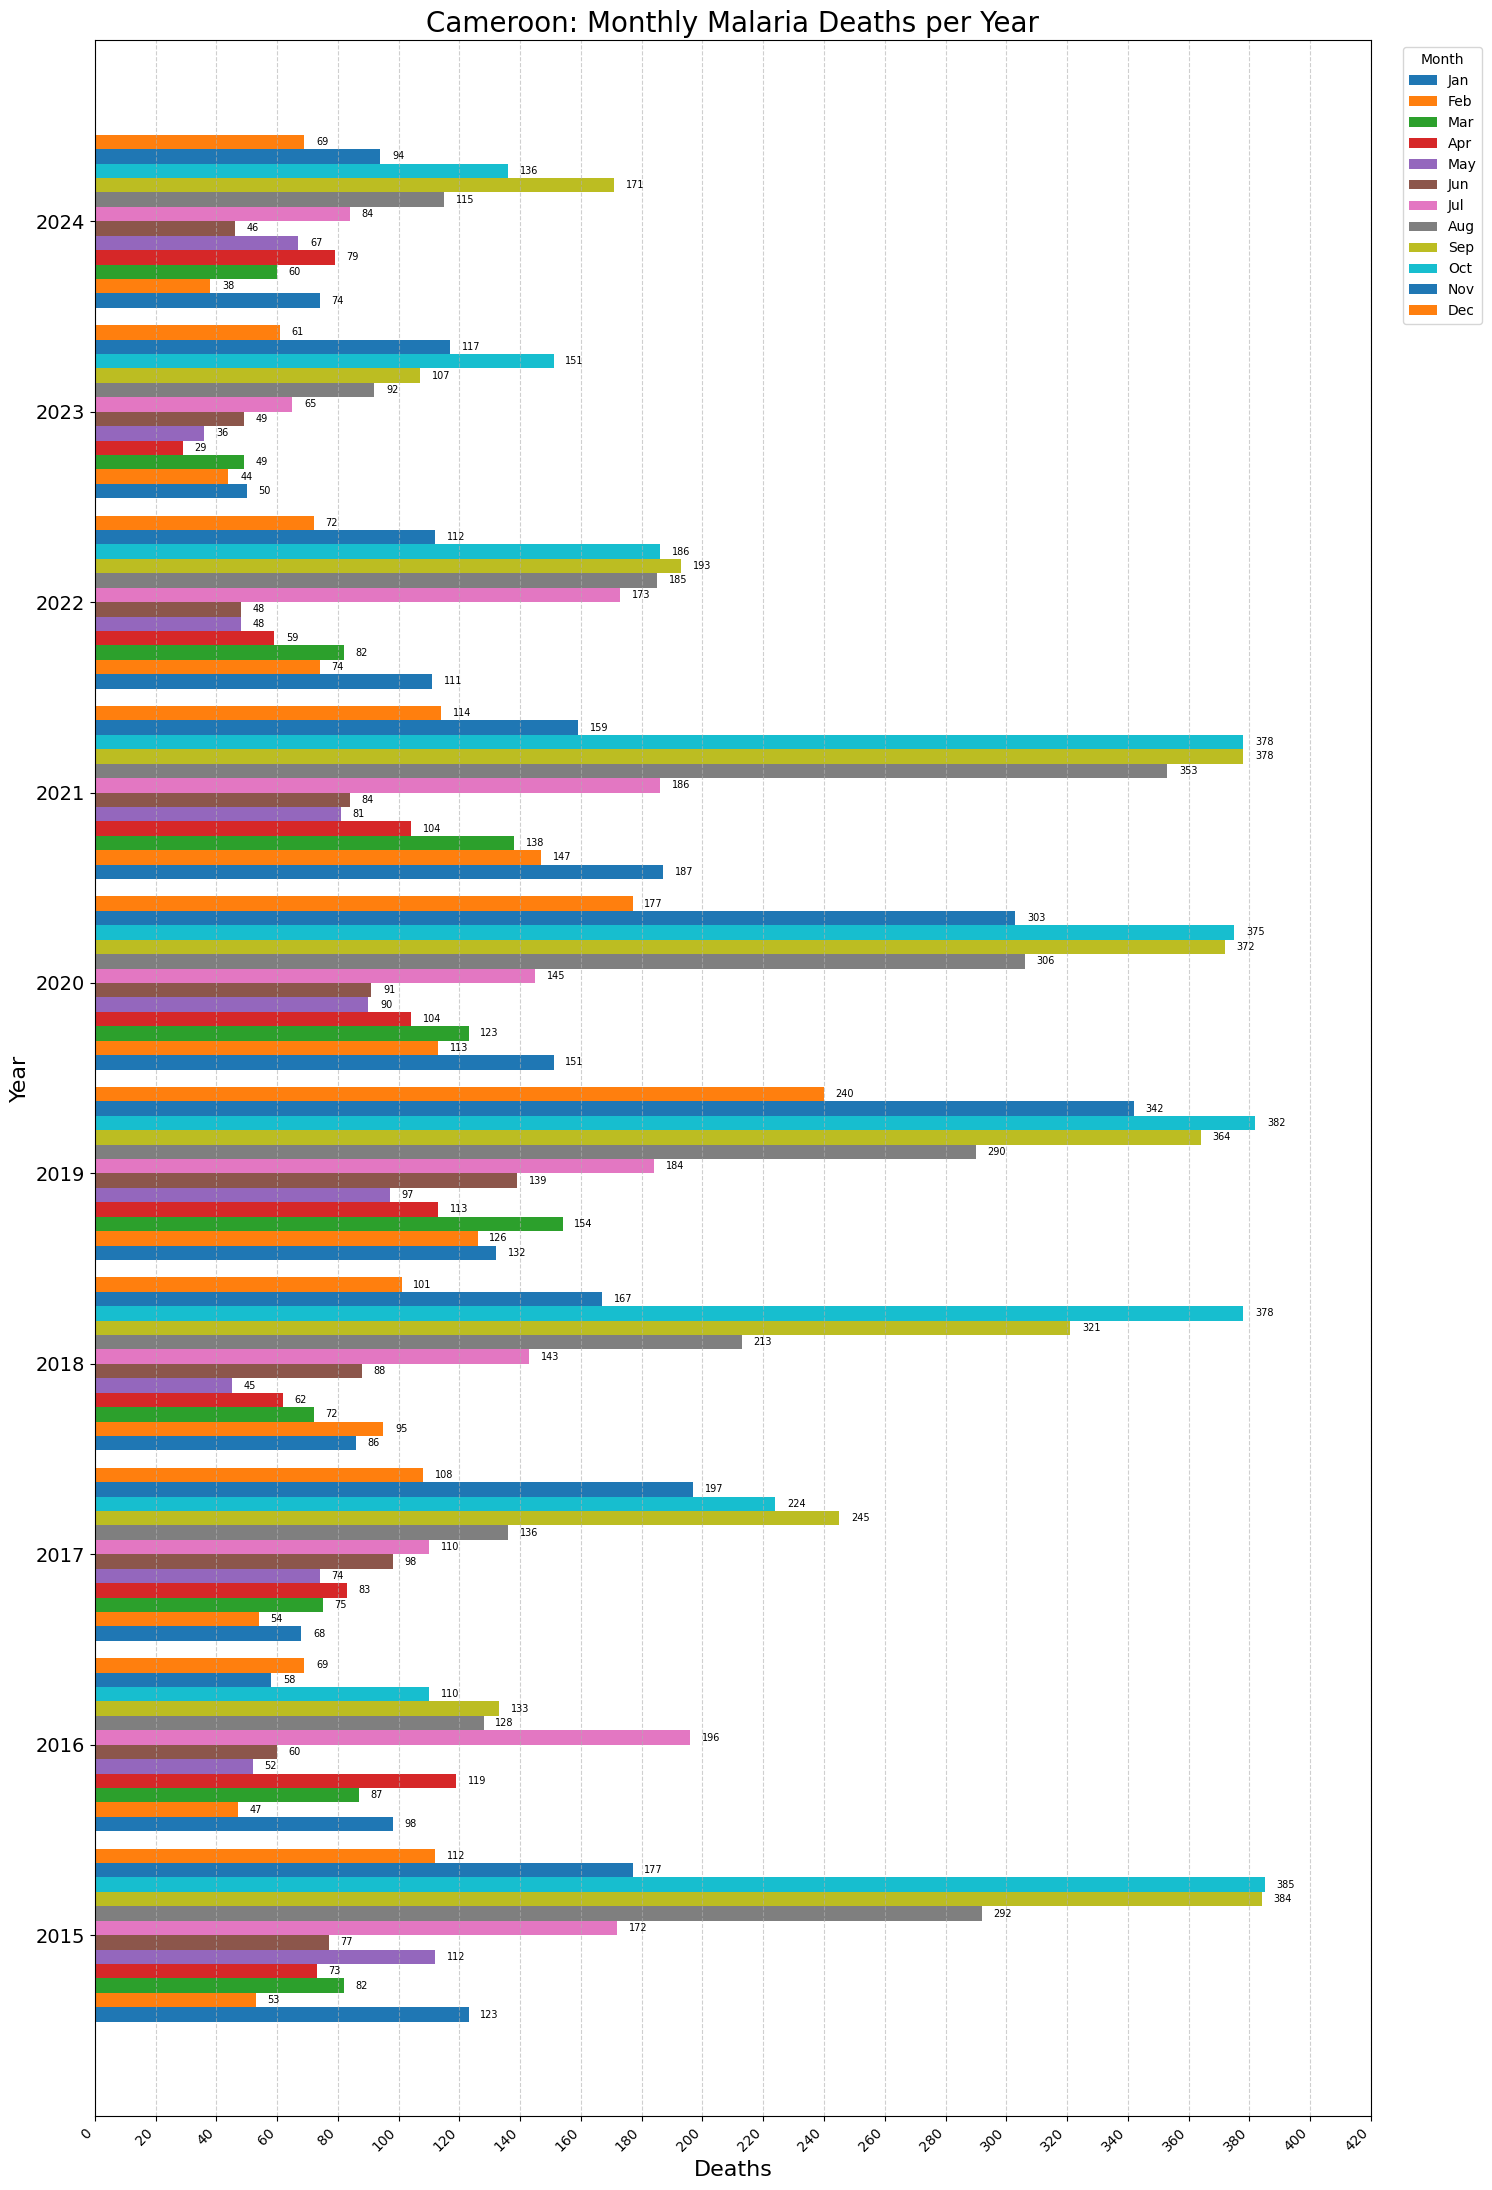

In [34]:
plot_monthly_yearly_horizontal_bars(df_deaths, 'Death_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22), x_ticks_rounding_factor=-1,
                                    title='Cameroon: Monthly Malaria Deaths per Year', xlabel='Deaths')

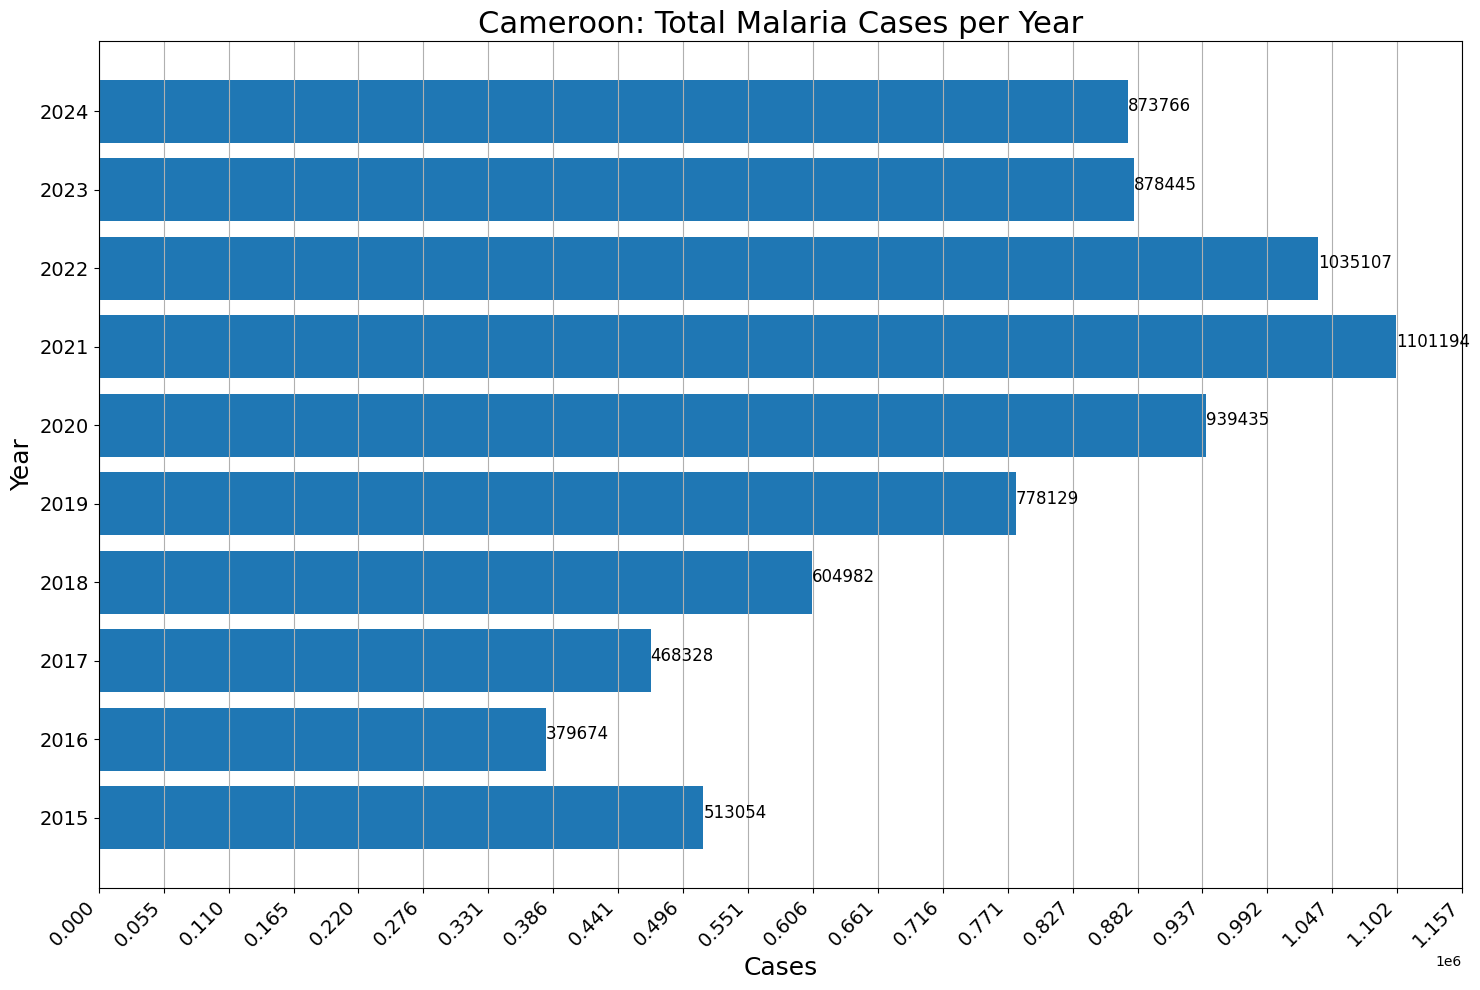

In [35]:
plot_grouped_barh(df_cases, group_col='Year', value_col='Case_TOTAL',
                          xlabel='Cases', ylabel='Year', title='Cameroon: Total Malaria Cases per Year')

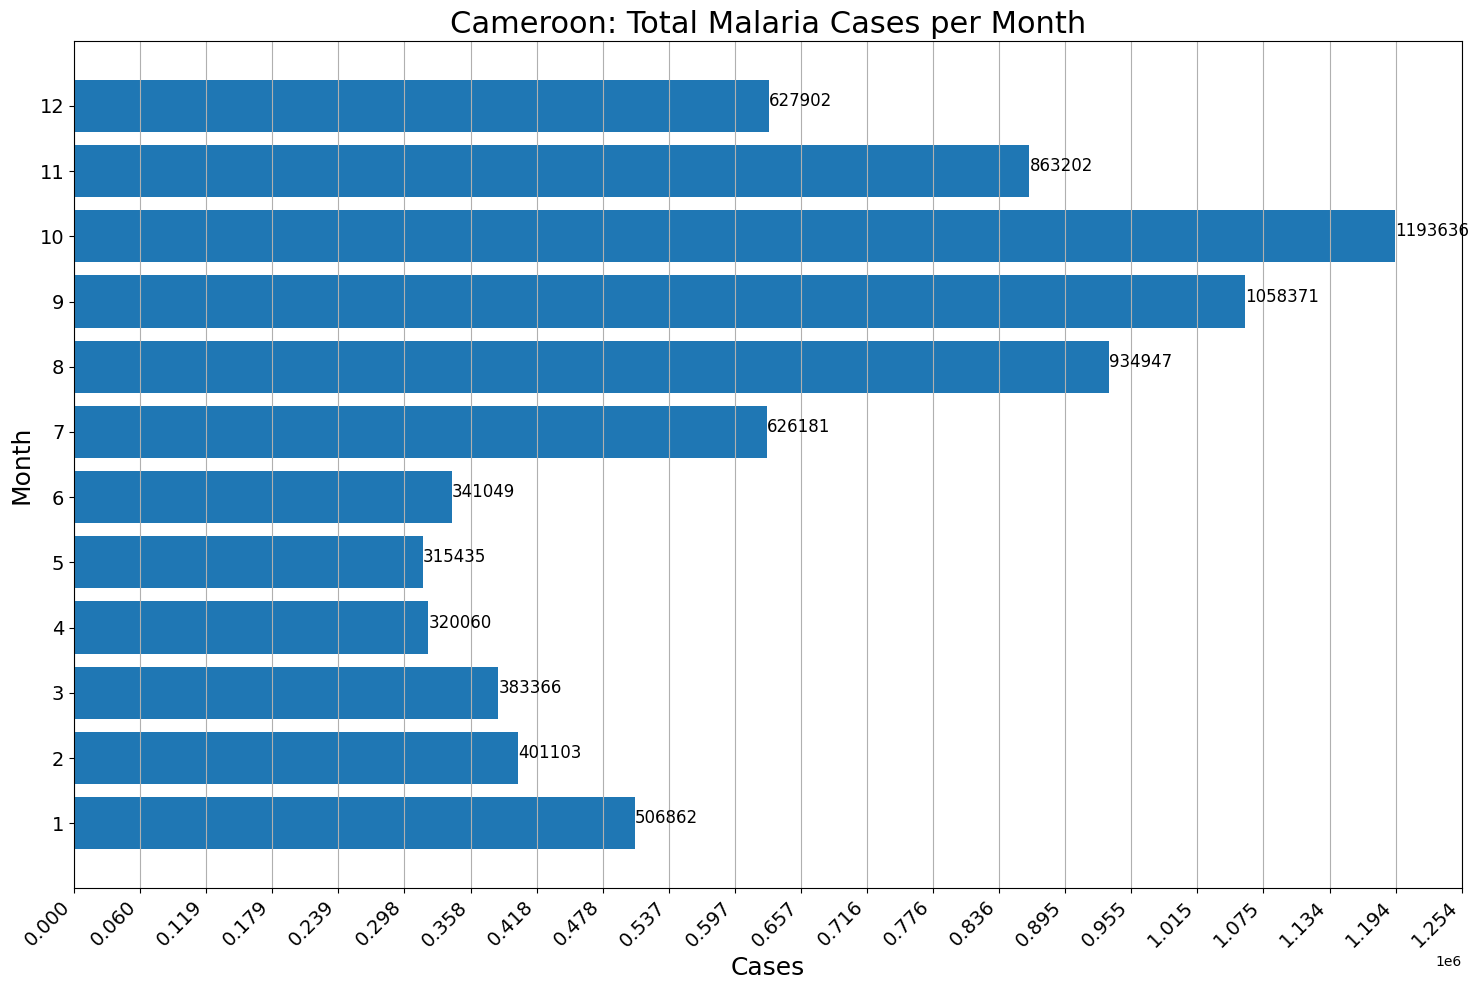

In [36]:
plot_grouped_barh(df_cases, group_col='Month', value_col='Case_TOTAL',
                          xlabel='Cases', ylabel='Month', title='Cameroon: Total Malaria Cases per Month')

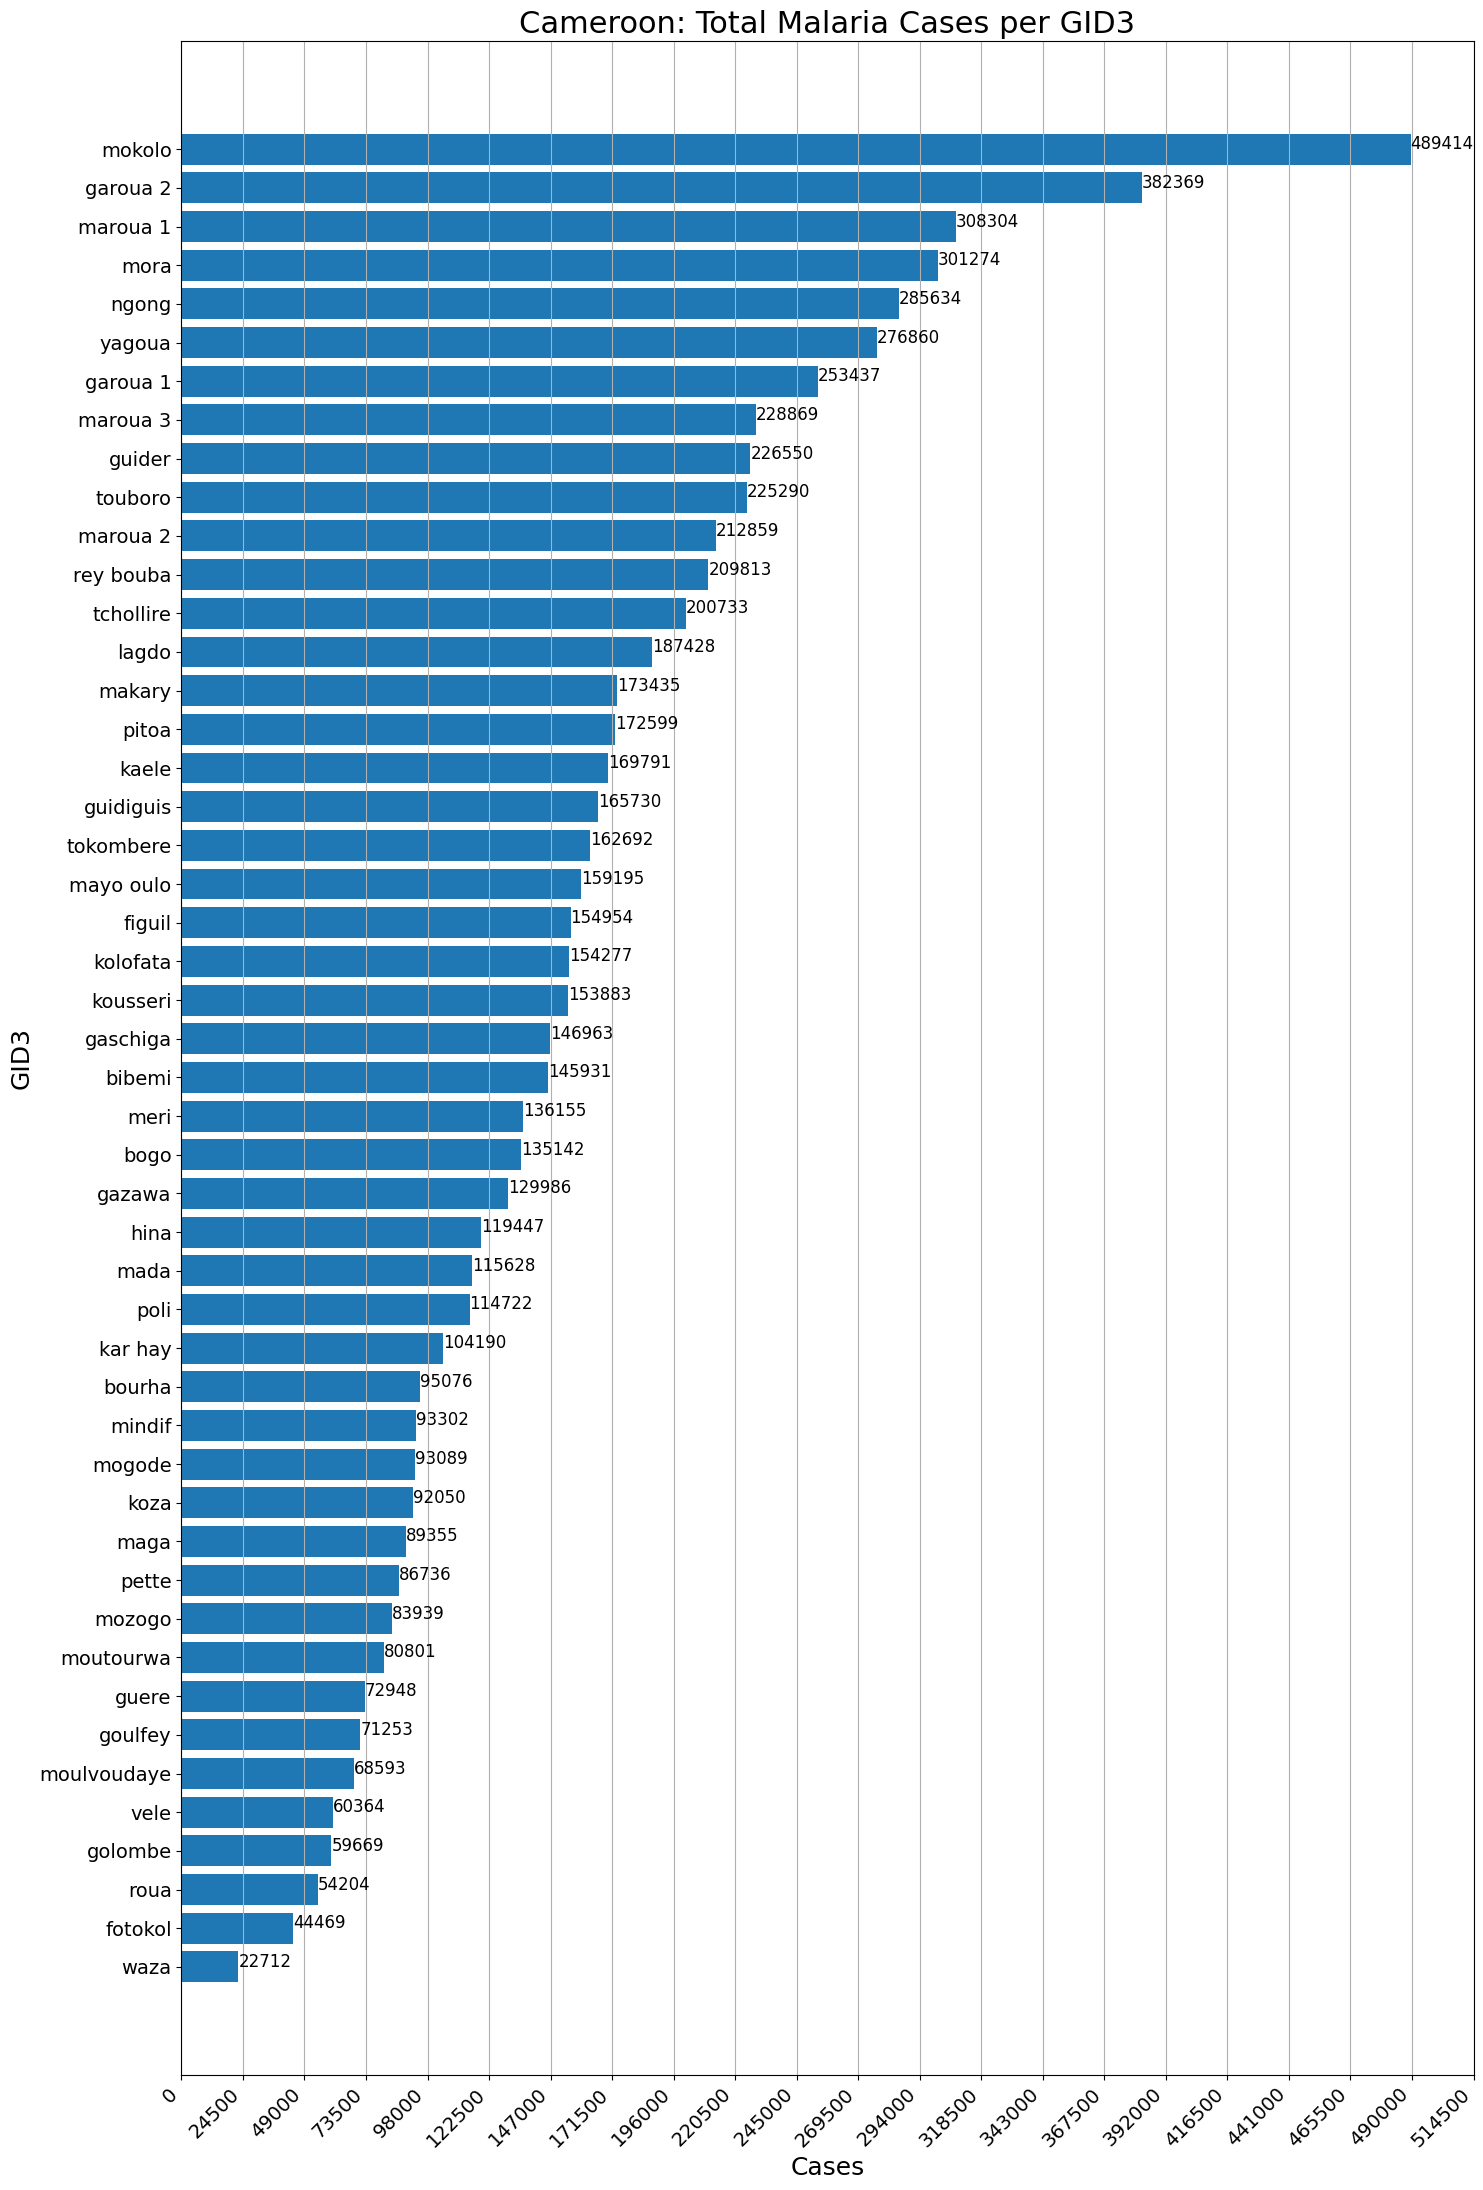

In [37]:
plot_grouped_barh(df_cases, group_col='GID3', value_col='Case_TOTAL',
                           xlabel='Cases', ylabel='GID3', title='Cameroon: Total Malaria Cases per GID3',
                           figsize=(15,22), text_size=12)

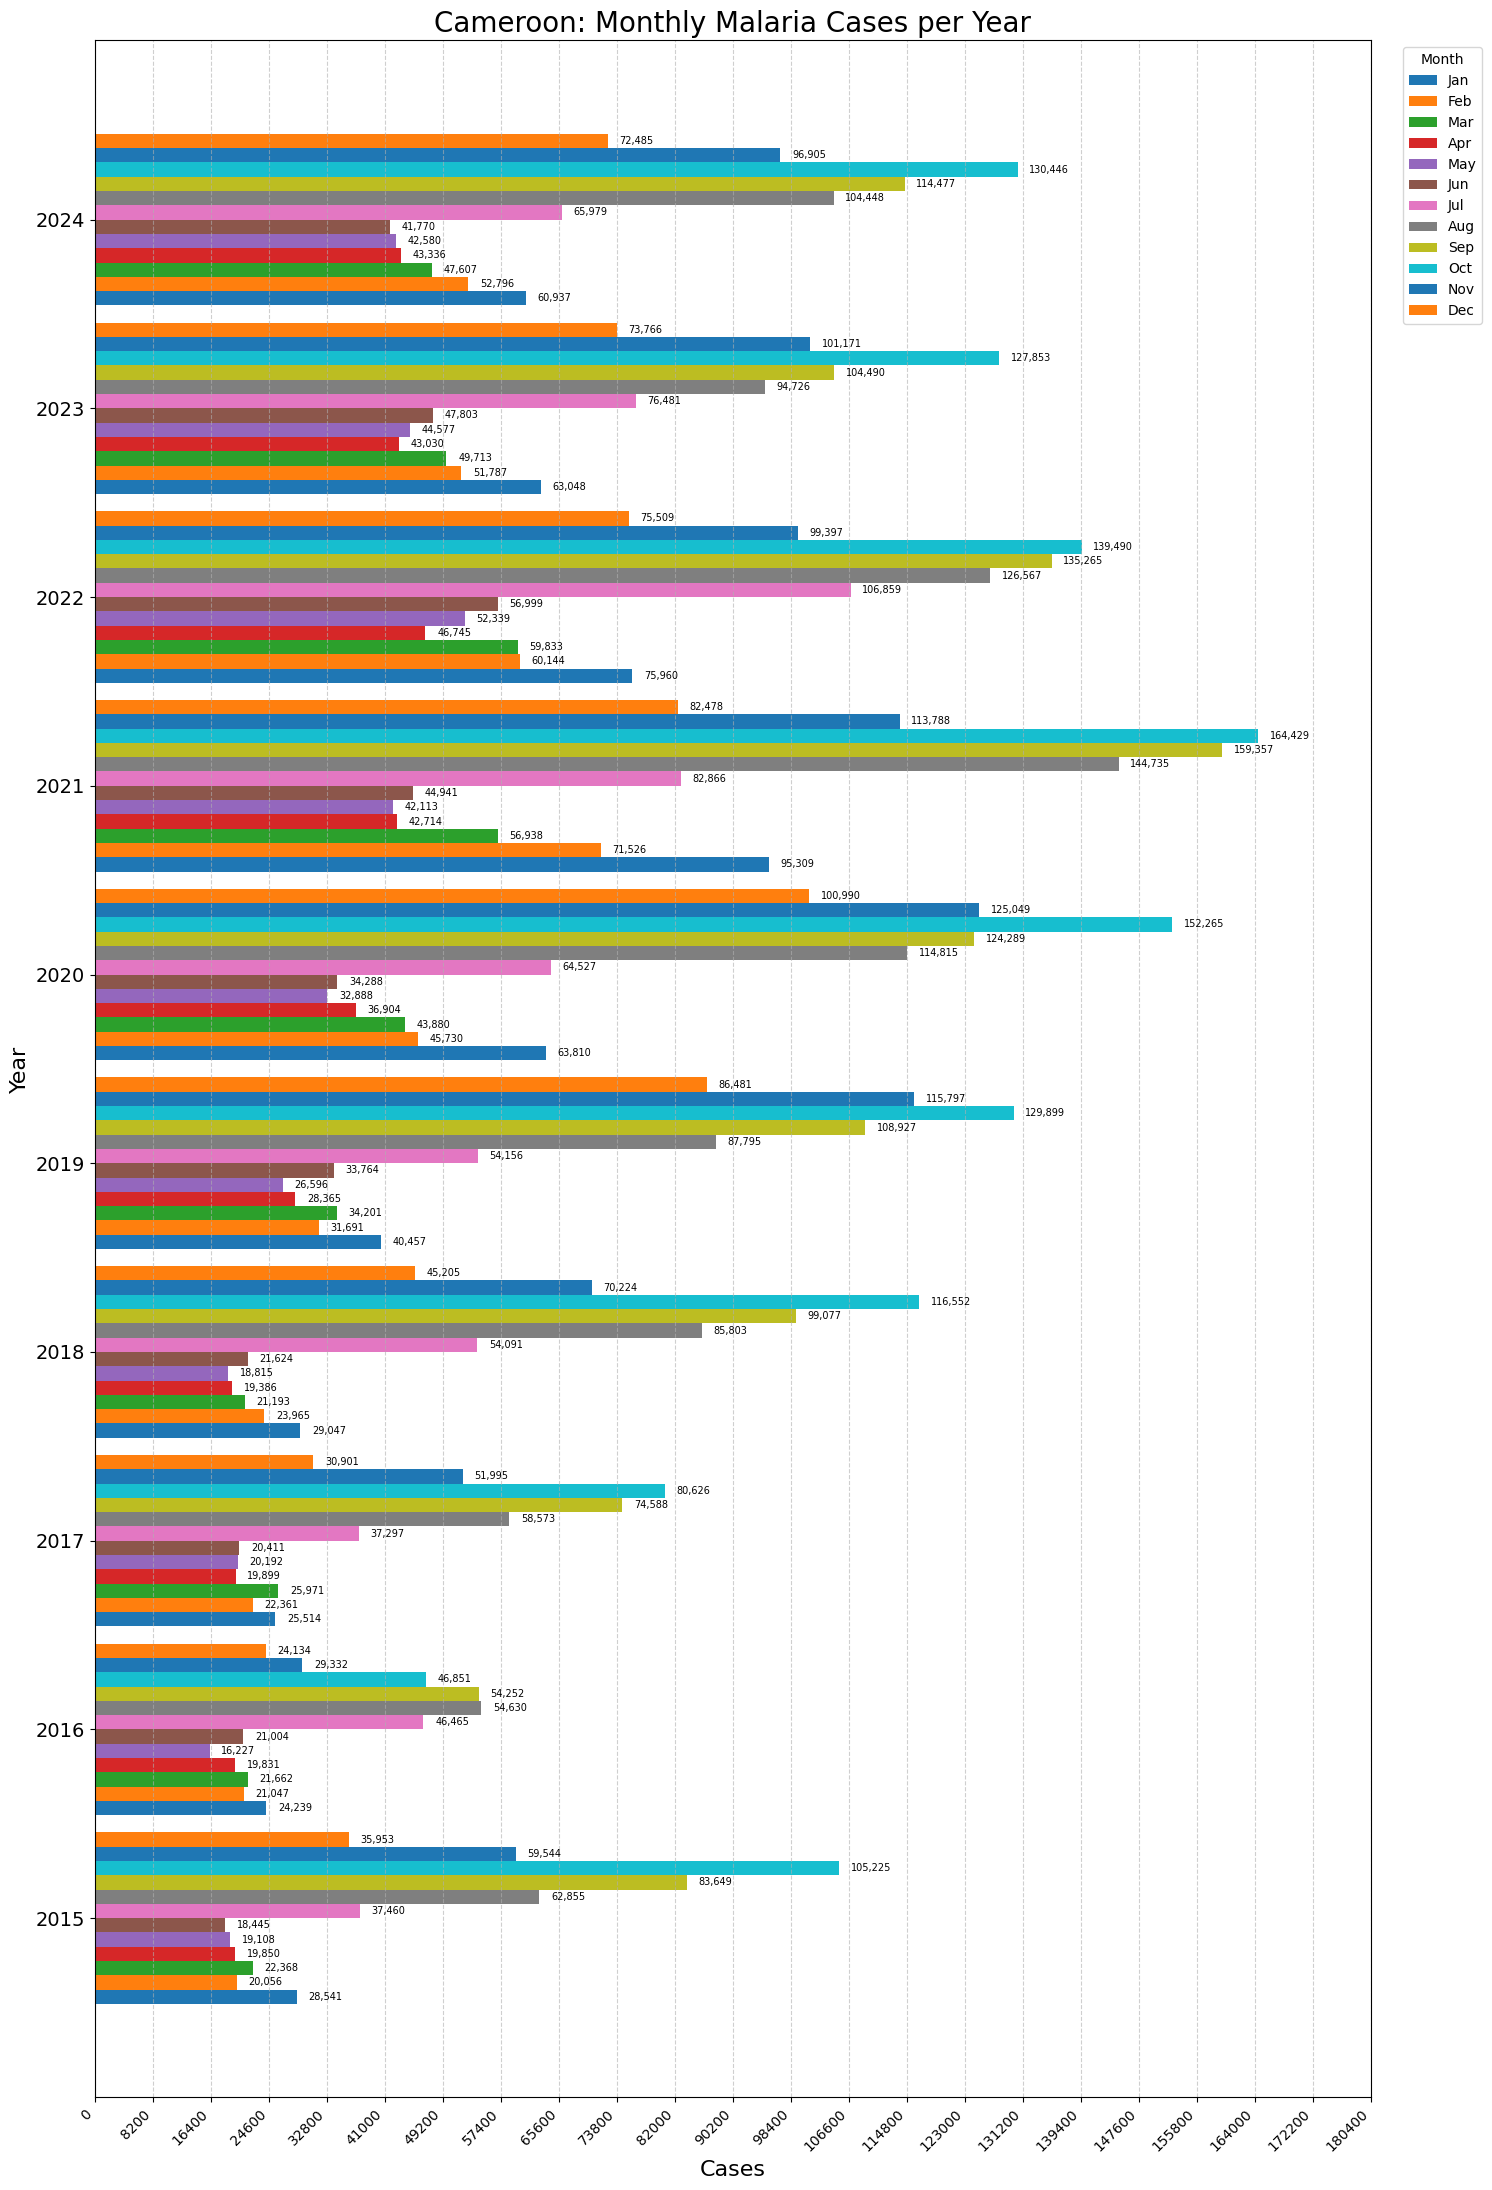

In [38]:
plot_monthly_yearly_horizontal_bars(df_cases, 'Case_TOTAL', bar_height_scale = 1.5, spacing_factor = 1.65, figsize=(15, 22),
                                    title='Cameroon: Monthly Malaria Cases per Year', xlabel='Cases')